# **Loan Default Prediction**

## **Problem Definition**

### **Context:**

A significant portion of a retail bank’s revenue comes from interest earned on home loans. However, loan defaults (non-performing assets) can severely impact profitability. Traditionally, loan approval decisions are made through manual evaluation of applicants’ financial and credit information. This process is time-consuming, prone to human error, and can introduce biases.

With the advancement of data science and machine learning, banks are shifting toward automated, data-driven credit scoring systems. These systems aim to improve efficiency, consistency, and objectivity in loan approval decisions while minimizing human bias.

---

### **Objective:**

The goal of this project is to develop a classification model that predicts whether a loan applicant is likely to default.

In addition to predictive performance, the model should be interpretable, enabling the bank to:
- justify loan approval or rejection decisions
- identify key risk factors associated with default
- support more informed and consistent lending strategies

---

### **key questions:**

This project seeks to answer the following key questions:

- What factors are most strongly associated with loan default?
- Can we accurately distinguish between high-risk and low-risk applicants?
- How does model performance vary across different modeling approaches?
- Which features should the bank prioritize when evaluating loan applications?
- What trade-offs exist between model accuracy and interpretability in this context?

---

### **The problem formulation**:

This is a supervised binary classification problem.

- **Target Variable:**  
  - `BAD = 1` → Applicant defaulted  
  - `BAD = 0` → Loan repaid  

- **Input Features:**  
  Applicant financial, credit, and demographic attributes

- **Goal:**  
  Learn a mapping  
  $$
  f(X) \rightarrow Y
  $$
  where:
  - $X$ represents applicant features  
  - $Y \in \{0,1\}$ represents default status  

The model will output the probability of default, which can then be used to:
- classify applicants into risk categories
- set decision thresholds for loan approval
- support risk-based lending policies

---

## **Data Description:**
The Home Equity dataset (HMEQ) contains baseline and loan performance information for 5,960 recent home equity loans. The target (BAD) is a binary variable that indicates whether an applicant has ultimately defaulted or has been severely delinquent. This adverse outcome occurred in 1,189 cases (20 percent). 12 input variables were registered for each applicant.


* **BAD:** 1 = Client defaulted on loan, 0 = loan repaid

* **LOAN:** Amount of loan approved.

* **MORTDUE:** Amount due on the existing mortgage.

* **VALUE:** Current value of the property.

* **REASON:** Reason for the loan request. (HomeImp = home improvement, DebtCon= debt consolidation which means taking out a new loan to pay off other liabilities and consumer debts)

* **JOB:** The type of job that loan applicant has such as manager, self, etc.

* **YOJ:** Years at present job.

* **DEROG:** Number of major derogatory reports (which indicates a serious delinquency or late payments).

* **DELINQ:** Number of delinquent credit lines (a line of credit becomes delinquent when a borrower does not make the minimum required payments 30 to 60 days past the day on which the payments were due).

* **CLAGE:** Age of the oldest credit line in months.

* **NINQ:** Number of recent credit inquiries.

* **CLNO:** Number of existing credit lines.

* **DEBTINC:** Debt-to-income ratio (all your monthly debt payments divided by your gross monthly income. This number is one way lenders measure your ability to manage the monthly payments to repay the money you plan to borrow.

## **Mounting the Drive**

In [5]:
import os

# Try to mount Drive (only works in Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
except:
    pass

COLAB_PATH = '/content/drive/MyDrive/Colab Notebooks/Python for Data Science/Loan Default Prediction'
KAGGLE_PATH = '/kaggle/input/hmeq-data'

if os.path.exists(COLAB_PATH):
    BASE_PATH = COLAB_PATH
else:
    BASE_PATH = KAGGLE_PATH

print("BASE_PATH =", BASE_PATH)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE_PATH = /content/drive/MyDrive/Colab Notebooks/Python for Data Science/Loan Default Prediction


## **Import the necessary libraries and Data**

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score,precision_score,recall_score,f1_score, roc_auc_score
from sklearn.metrics import precision_recall_curve

from sklearn.preprocessing import StandardScaler

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier

import scipy.stats as stats

from sklearn.model_selection import GridSearchCV


import warnings
warnings.filterwarnings('ignore')

## **Data Overview**

- Reading the dataset
- Understanding the shape of the dataset
- Checking the data types
- Checking for missing values
- Checking for duplicated values

In [7]:
# Reading the dataset
hmeq = pd.read_csv(os.path.join(BASE_PATH, 'hmeq.csv'))

In [8]:
# Copying data to another variable to avoid any changes to original data
df = hmeq.copy()

## Summary Statistics

In [9]:
df.sample(5)

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
982,0,9300,81986.0,94513.0,DebtCon,Other,2.0,3.0,0.0,NaN,0.0,4.0,31.893904
4223,0,22000,48000.0,80990.0,DebtCon,Mgr,6.0,0.0,0.0,262.733333,2.0,26.0,NaN
86,1,4000,41700.0,76725.0,HomeImp,Other,0.5,0.0,3.0,136.133333,0.0,15.0,NaN
5623,0,38200,147457.0,210065.0,HomeImp,ProfExe,3.0,0.0,0.0,148.733185,0.0,31.0,35.894925
2739,0,15500,59316.0,80837.0,DebtCon,Other,1.0,0.0,0.0,126.912723,3.0,11.0,35.901463


In [10]:
df.shape

(5960, 13)

The dataset contains `5960` rows and `13` columns.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   object 
 5   JOB      5681 non-null   object 
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB


In [12]:
df.describe().T #include='all'

,count,mean,std,min,25%,50%,75%,max
BAD,5960.0,0.199497,0.399656,0.000000,0.000000,0.000000,0.000000,1.000000
LOAN,5960.0,18607.969799,11207.480417,1100.000000,11100.000000,16300.000000,23300.000000,89900.000000
MORTDUE,5442.0,73760.817200,44457.609458,2063.000000,46276.000000,65019.000000,91488.000000,399550.000000
VALUE,5848.0,101776.048741,57385.775334,8000.000000,66075.500000,89235.500000,119824.250000,855909.000000
YOJ,5445.0,8.922268,7.573982,0.000000,3.000000,7.000000,13.000000,41.000000
DEROG,5252.0,0.254570,0.846047,0.000000,0.000000,0.000000,0.000000,10.000000
DELINQ,5380.0,0.449442,1.127266,0.000000,0.000000,0.000000,0.000000,15.000000
CLAGE,5652.0,179.766275,85.810092,0.000000,115.116702,173.466667,231.562278,1168.233561
NINQ,5450.0,1.186055,1.728675,0.000000,0.000000,1.000000,2.000000,17.000000
CLNO,5738.0,21.296096,10.138933,0.000000,15.000000,20.000000,26.000000,71.000000


In [13]:
df.duplicated().sum()

np.int64(0)

- There are no duplicate records in the dataset.


## **Exploratory Data Analysis (EDA) and Visualization**

**Leading Questions**:
1. What is the range of values for the loan amount variable "LOAN"?
2. How does the distribution of years at present job "YOJ" vary across the dataset?
3. How many unique categories are there in the REASON variable?
4. What is the most common category in the JOB variable?
5. Is there a relationship between the REASON variable and the proportion of applicants who defaulted on their loan?
6. Do applicants who default have a significantly different loan amount compared to those who repay their loan?
7. Is there a correlation between the value of the property and the loan default rate?
8. Do applicants who default have a significantly different mortgage amount compared to those who repay their loan?

### **Univariate Analysis**


**Target Variable Analysis**

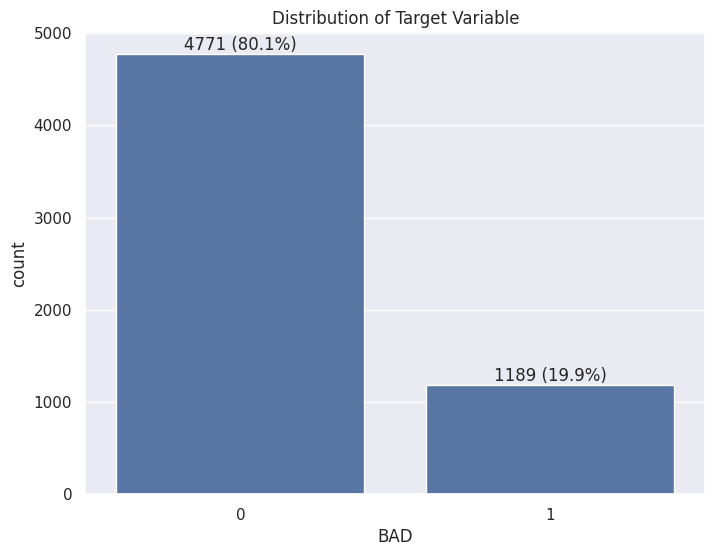

In [14]:
plt.figure(figsize=(8, 6))

ax = sns.countplot(data=df, x='BAD')

plt.title('Distribution of Target Variable')

# Total number of observations
total = len(df)

# Annotate each bar
for p in ax.patches:
    count = int(p.get_height())
    percentage = count / total * 100
    ax.annotate(f'{count} ({percentage:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.show()

- The dataset is highly imbalanced, with a significantly larger proportion of non-defaulters (`BAD = 0`) compared to defaulters (`BAD = 1`).
- Approximately 80% of applicants did not default, while only about 20% defaulted.
- This class imbalance can bias models toward predicting the majority class, leading to misleading accuracy.
- As a result, evaluation should focus on metrics such as precision, recall, F1-score, and ROC-AUC, rather than accuracy alone.
- Techniques such as resampling or class weighting may be necessary during modeling.

**Missing Values Analysis**

In [15]:
def plot_missing(df):
    missing = df.isnull().sum().sort_values(ascending=False)

    plt.figure(figsize=(10,5))
    ax = sns.barplot(x=missing.index, y=missing.values)

    # Annotate percentages
    total = len(df)
    for i, j in enumerate(missing.values):
        pct = (j / total) * 100
        ax.text(i, j + (0.01 * total), f'{pct:.1f}%', ha='center')

    plt.title('Missing Values Count (with %)')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

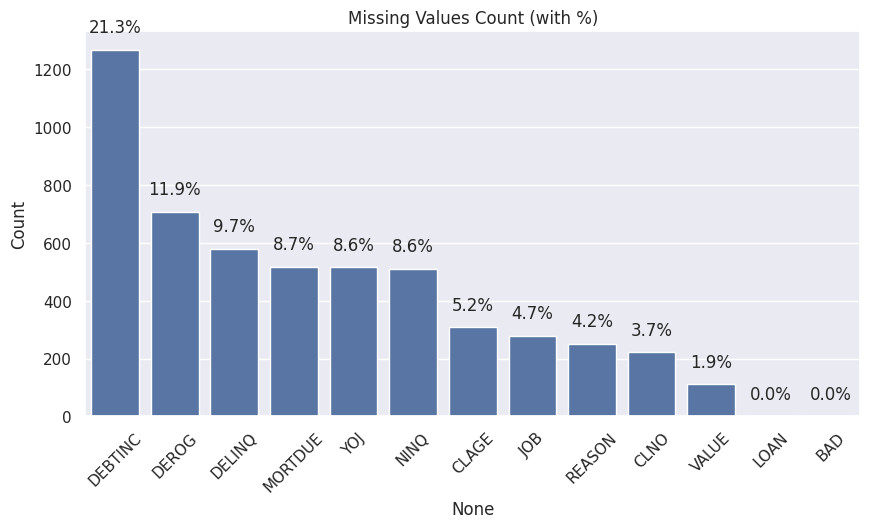

In [16]:
plot_missing(df)

- `DEBTINC` has the highest missing values (`~21%`), making it a critical feature requiring careful imputation or treatment.
- `DEROG` (`~12%`) and `DELINQ` (`~10%`) also show notable missing values, which is important since they are key credit risk indicators.
- Several features (`MORTDUE`, `YOJ`, `NINQ`) have moderate missing values (`~8–9%`)**, suggesting a consistent pattern of incomplete financial/credit records.
- Categorical variables (`JOB`, `REASON`) have relatively low missing values (`<5%`), making them easier to handle.
- `LOAN` and `BAD` have no missing values, ensuring reliability for modeling and target prediction.

Overall, missingness is non-trivial and widespread, indicating that a robust imputation strategy will be essential before modeling.

**Feature Ditributions**

In [17]:
def plot_distribution(df, col, log=False, kde = True):

    if log:
        # Create log column
        log_col = f"{col}_log"
        df[log_col] = np.log1p(df[col])

        plt.figure(figsize=(12, 4))

        # Original histogram
        plt.subplot(1, 3, 1)
        sns.histplot(df[col].dropna(), bins=30, kde=kde)
        plt.title(f'Original {col}')

        # Boxplot
        plt.subplot(1, 3, 2)
        sns.boxplot(x=df[col])
        plt.title(f'Boxplot of {col}')

        # Log-transformed histogram
        plt.subplot(1, 3, 3)
        sns.histplot(df[log_col].dropna(), bins=30, kde=kde)
        plt.title(f'Log-Transformed {col}')

    else:
        plt.figure(figsize=(10, 4))

        # Histogram
        plt.subplot(1, 2, 1)
        sns.histplot(df[col].dropna(), bins=30, kde=kde)
        plt.title(f'Distribution of {col}')

        # Boxplot
        plt.subplot(1, 2, 2)
        sns.boxplot(x=df[col])
        plt.title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

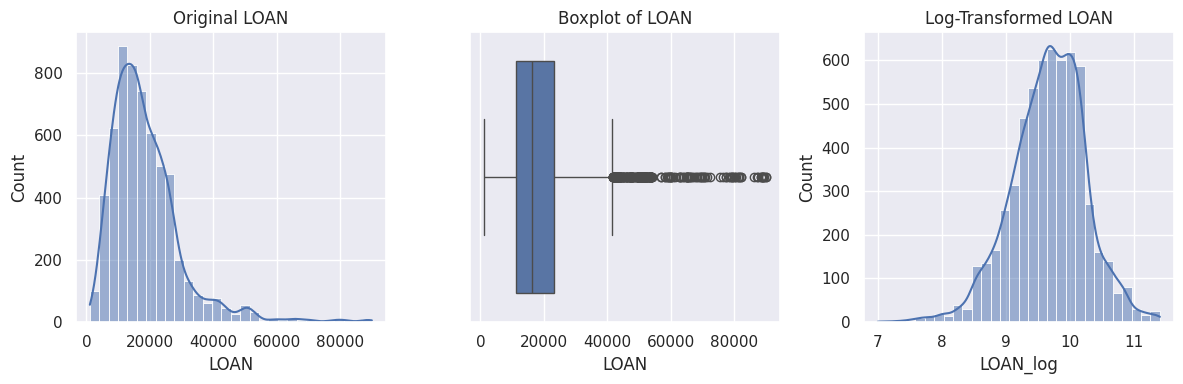

In [18]:
plot_distribution(df, 'LOAN', log = True)

- The distribution of `LOAN` is right-skewed, with most loans concentrated between lower to mid-range values.
- There is a long right tail, indicating the presence of a few very high loan amounts.
- The boxplot confirms numerous high-value outliers, suggesting significant variability in loan sizes.
- This skewness may impact model performance, indicating that log transformation or scaling could be beneficial.
  - After log transformation, the distribution becomes more symmetric and approximately normal, with reduced skewness.
  - Extreme values are compressed,reducing the influence of outliers.
  - This transformation makes the feature more suitable for models sensitive to scale and distribution.
- Larger loan amounts may be associated with higher financial risk, making this feature potentially important for predicting default.

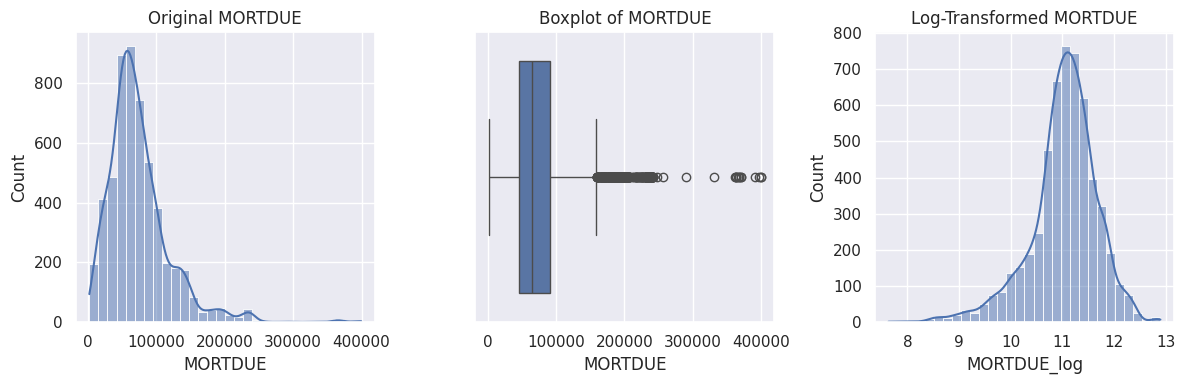

In [19]:
plot_distribution(df, 'MORTDUE', log = True)

- The original `MORTDUE` distribution is strongly right-skewed, with most values concentrated at lower ranges and a long tail of high mortgage balances.
- The boxplot shows numerous high-value outliers, indicating significant variability and extreme cases.
  - After log transformation, the distribution becomes more symmetric and bell-shaped, with reduced skewness.
  - Extreme values are effectively compressed, improving the spread of the data.

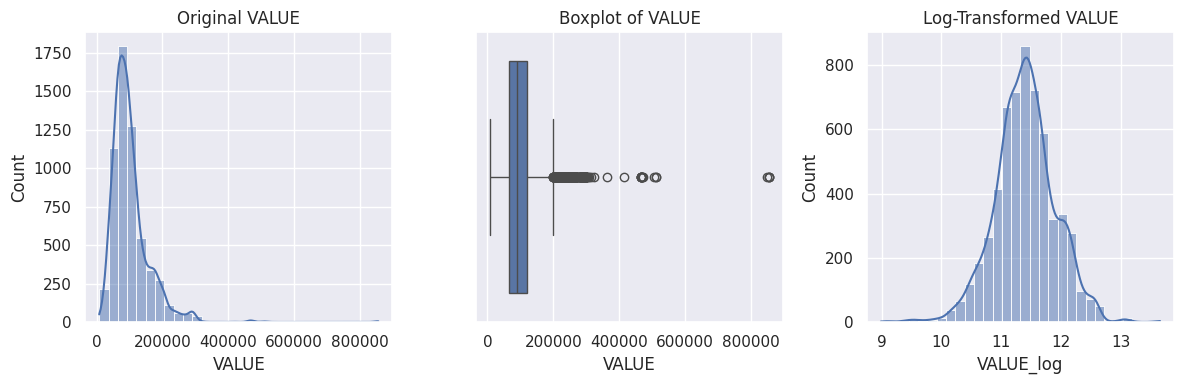

In [20]:
plot_distribution(df, 'VALUE', log = True)

- The original `VALUE` distribution is highly right-skewed, with most property values concentrated at lower ranges and a long tail of expensive properties.
- The boxplot indicates many high-value outliers, reflecting substantial variation in property prices.
  - After log transformation, the distribution becomes more symmetric and closer to normal, reducing skewness.
  - Extreme values are compressed, leading to a more balanced representation of the data.

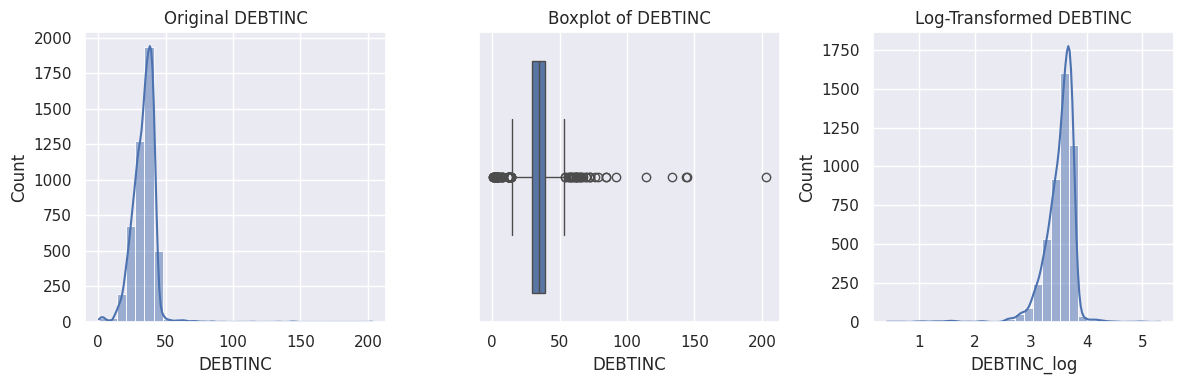

In [21]:
plot_distribution(df, 'DEBTINC', log = True)

- The original `DEBTINC` distribution is right-skewed, with most values concentrated between 20–50, and a long tail of extreme values.
- The boxplot confirms the presence of significant high-value outliers, which could distort model learning.
  - After log transformation, the distribution becomes more symmetric and tightly centered, with reduced skewness.
  - Extreme values are substantially compressed, improving the overall spread of the data.

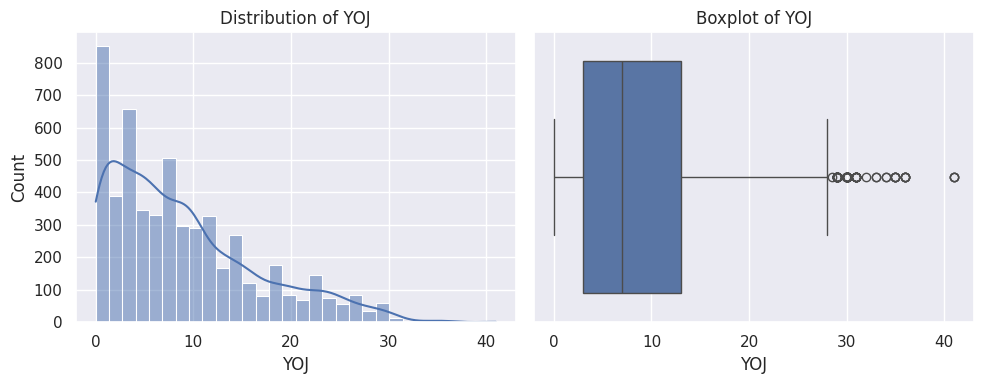

In [22]:
plot_distribution(df, 'YOJ')

- The distribution of `YOJ` (years on job) is right-skewed, with a high concentration of applicants having low tenure (0–10 years).
- There is a gradual decline as years increase, indicating fewer long-tenured employees.
- The boxplot shows some high-value outliers (30+ years), but they are not excessively extreme.
- A noticeable number of values near 0 years may indicate new or unstable employment, which could be relevant for credit risk.

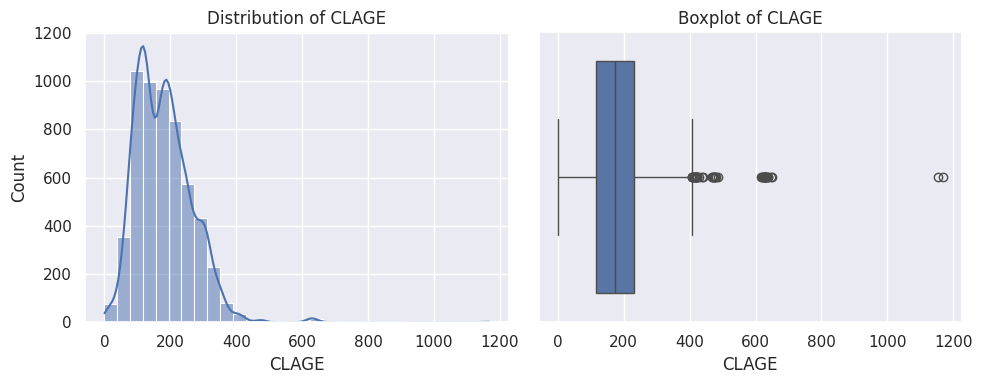

In [23]:
plot_distribution(df, 'CLAGE')

- The distribution of `CLAGE` (age of oldest credit line) is right-skewed, with most values concentrated between 100–250 months.
- There is a long right tail, indicating a small number of applicants with very long credit histories.
- The boxplot shows several high-value outliers, which likely represent genuinely long-established credit histories rather than noise.
- The bulk of applicants have moderate credit history length, which is typical in lending datasets.

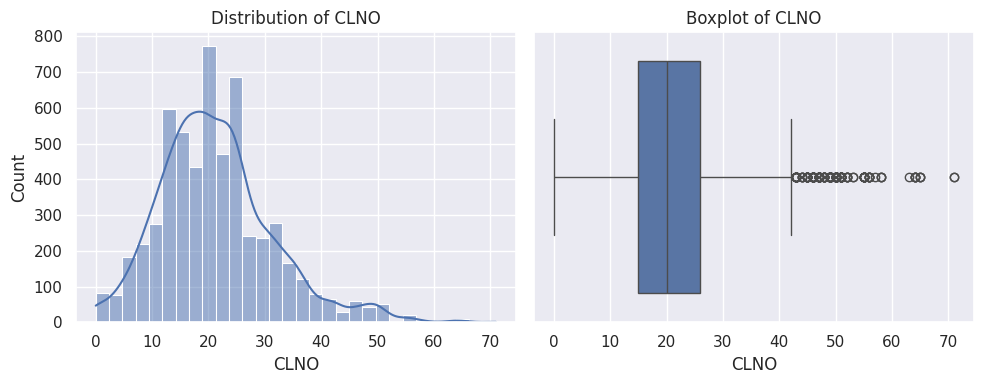

In [24]:
plot_distribution(df, 'CLNO')

- The distribution of `CLNO` (number of credit lines) is slightly right-skewed, with most applicants having 10–30 credit lines.
- The distribution is relatively well-spread and unimodal, indicating natural variation across applicants.
- The boxplot shows some high-value outliers (above ~45), but these are not extreme relative to the feature range.
- The presence of multiple credit lines is common, and higher values may reflect greater credit exposure or experience.

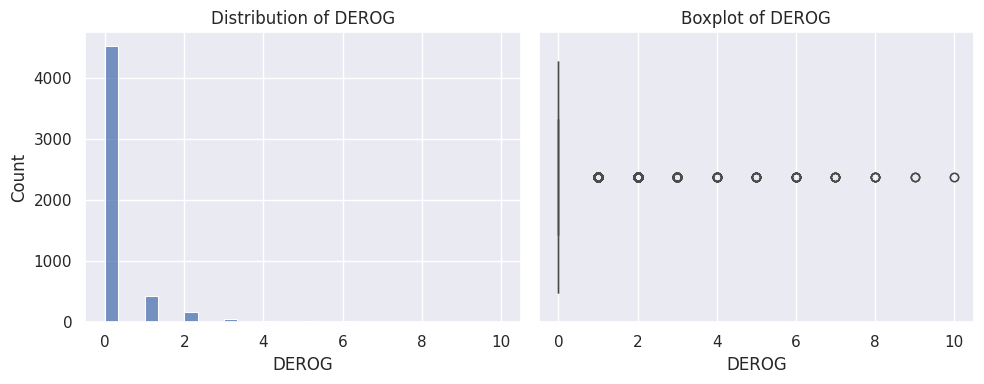

In [25]:
plot_distribution(df, 'DEROG', kde = False)

- The distribution of `DEROG` (number of major derogatory reports) is highly right-skewed, with a large concentration at 0.
- Most applicants have no derogatory reports, while a small number have 1–2, and very few have higher counts.
- The boxplot shows multiple “outliers,” but these are valid discrete values, rather than anomalies.
- This feature is effectively zero-inflated and discrete, not continuous.
---
KEEP IN MIND
---

- Consider treating it as:
  - a **numerical count variable**, or  
  - a **binary indicator (DEROG > 0)** during feature engineering.
- This is a **strong risk indicator**, as any non-zero value likely signals elevated default risk.

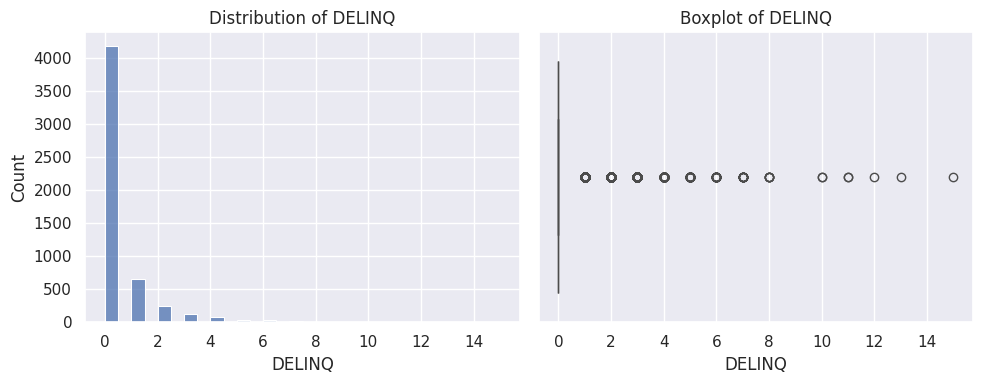

In [26]:
plot_distribution(df, 'DELINQ', kde=False)

- The distribution of `DELINQ` (number of delinquent credit lines) is highly right-skewed, with a strong concentration at 0.
- Most applicants have no delinquent credit lines, while a small number have 1 or more.
- The boxplot shows multiple higher values, but these are valid discrete counts.
- Similar to `DEROG`, this feature is zero-inflated and discrete, indicating a threshold-type behavior.

---
KEEP IN MIND
---

- Consider creating a **binary indicator (DELINQ > 0)** during feature engineering.
- This is a **strong risk indicator**, as any history of delinquency likely increases default risk.

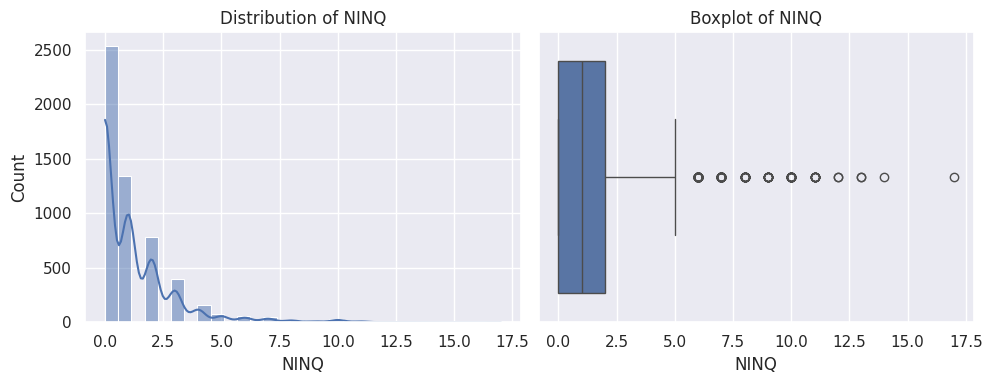

In [27]:
plot_distribution(df, 'NINQ')

- The distribution of `NINQ` (number of recent credit inquiries) is right-skewed, with most values concentrated at 0–2 inquiries.
- A large proportion of applicants have few to no recent inquiries, while a small number have higher counts.
- The boxplot shows higher values, but these are valid discrete counts, rather than anomalies.
- The feature exhibits mild zero-inflation, though less extreme than `DEROG` and `DELINQ`.

This feature may capture recent credit-seeking behavior, which can be relevant for risk assessment.

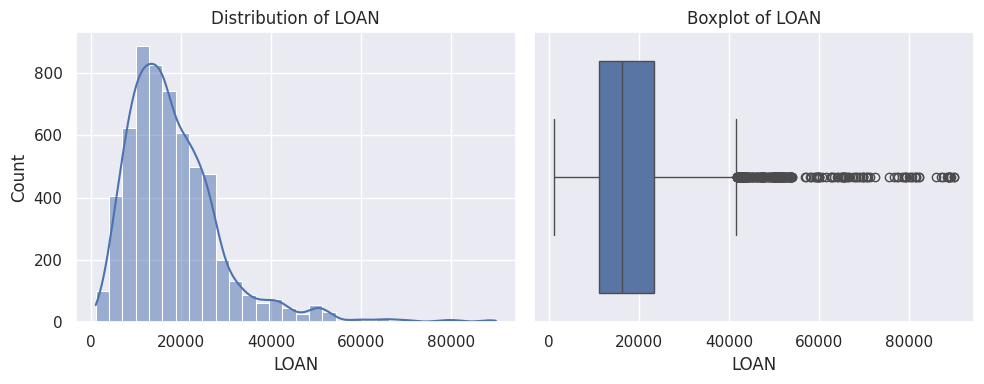

In [28]:
plot_distribution(df, 'LOAN')

In [29]:
def plot_categorical(df, col):

    plt.figure(figsize=(6, 4))

    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

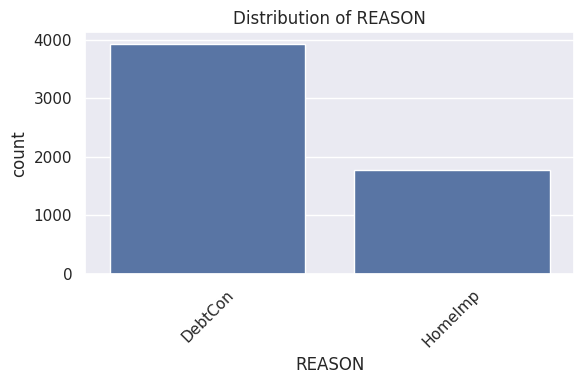

In [30]:
plot_categorical(df, 'REASON')

- The majority of loan applications are for debt consolidation (DebtCon), significantly outnumbering home improvement (HomeImp) requests.
- This indicates that most borrowers are seeking loans to manage existing debt rather than invest in property improvements.
- The imbalance suggests that loan purpose may influence default risk, as debt consolidation is often associated with higher financial stress.

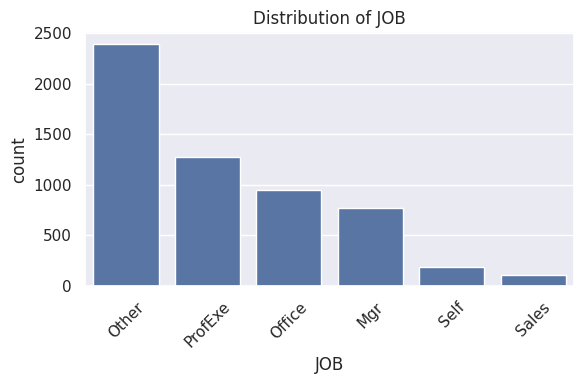

In [31]:
plot_categorical(df, 'JOB')

- The most common job category is "Other", followed by "ProfExe" (Professional/Executive) and *"Office" roles.
- Categories such as "Self" and "Sales" have relatively low representation.
- The distribution is imbalanced across categories, with a few dominant groups and several minority classes.
- This imbalance may impact modeling, especially if some categories have insufficient data for reliable pattern learning.

---
KEEP IN MIND
---

- Consider grouping rare categories if needed during preprocessing.
- Evaluate its relationship with default risk in **bivariate analysis (JOB vs BAD)**.

### **Bivariate Analysis**

In [32]:
def plot_numeric_vs_target(df, col, target='BAD'):

    plt.figure(figsize=(10, 4))

    # Boxplot
    plt.subplot(1, 2, 1)
    sns.boxplot(x=target, y=col, data=df)
    plt.title(f'{col} vs {target}')

    # KDE / Distribution
    plt.subplot(1, 2, 2)
    sns.kdeplot(data=df, x=col, hue=target, common_norm=False)
    plt.title(f'Distribution of {col} by {target}')

    plt.tight_layout()
    plt.show()

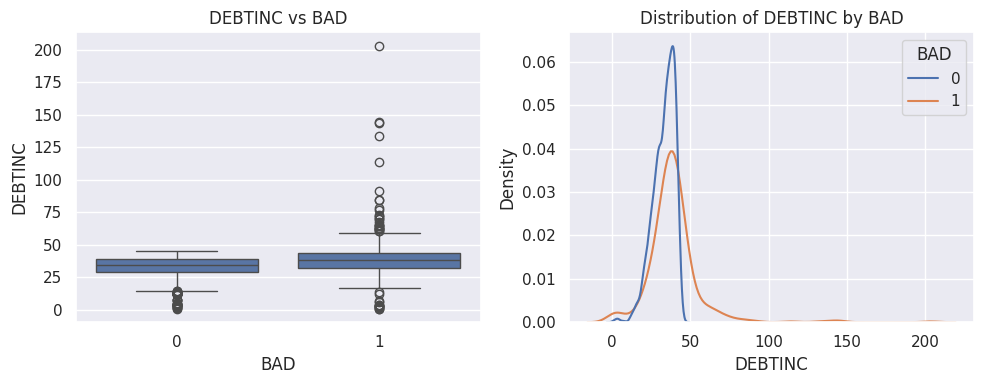

In [33]:
plot_numeric_vs_target(df, 'DEBTINC')

- Defaulters (`BAD = 1`) generally have higher DEBTINC values compared to non-defaulters, as seen from the upward shift in the boxplot.
- The distribution for defaulters is more spread out with a heavier right tail, indicating greater financial strain among this group.
- There is noticeable overlap between the two classes, but defaulters show a higher concentration at elevated DEBTINC levels.
- Extreme DEBTINC values are predominantly associated with defaulters, reinforcing its role as a risk indicator.

`DEBTINC` is a strong predictor of default risk, where higher debt-to-income ratios are associated with increased likelihood of default.

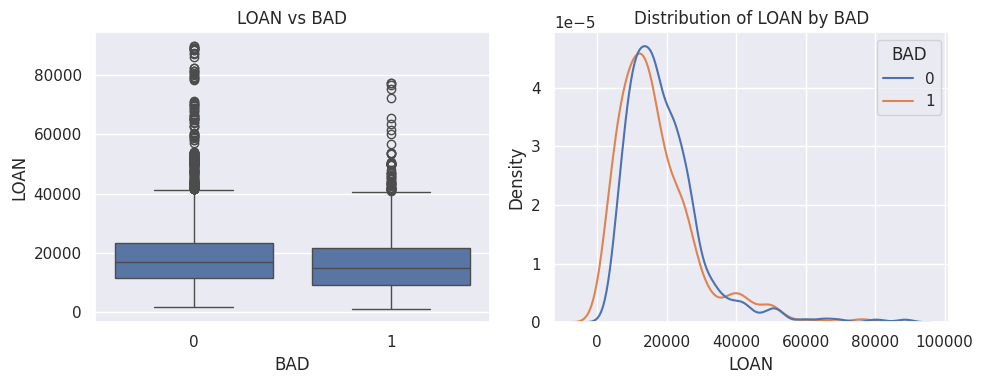

In [34]:
plot_numeric_vs_target(df, 'LOAN')

- The distributions of `LOAN` for defaulters and non-defaulters are highly overlapping, indicating weak separation.
- The median loan amount for defaulters appears slightly lower than for non-defaulters.
- Both groups exhibit similar spread and outlier patterns, with high loan amounts present in both classes.
- The KDE plots show very similar shapes, suggesting limited discriminative power.

`LOAN` alone is a weak predictor of default, as loan size does not clearly distinguish between defaulters and non-defaulters.

Its predictive value may emerge when combined with other features (e.g., income-related ratios).

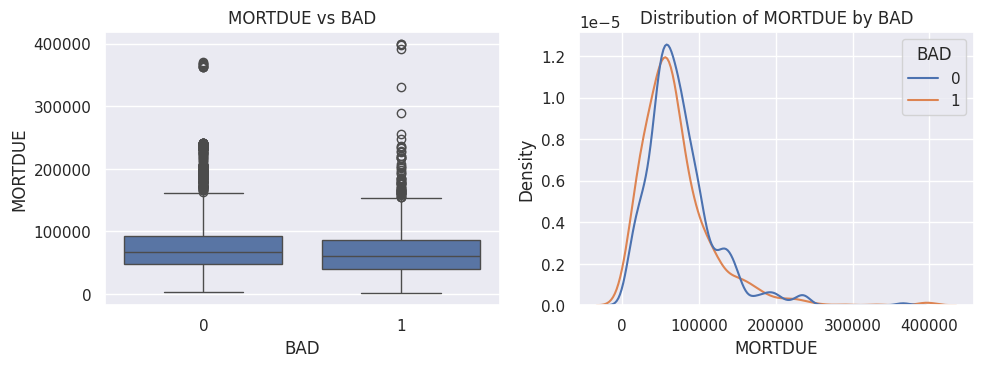

In [35]:
plot_numeric_vs_target(df, 'MORTDUE')

- The distributions of `MORTDUE` for defaulters and non-defaulters are heavily overlapping, with very similar central tendencies.
- The median mortgage due for defaulters is slightly lower, but the difference is minimal.
- Both groups show wide variability and significant right-skew, with large outliers present in each class.
- KDE curves are very similar, indicating limited separation between the two groups.

`MORTDUE` is a weak standalone predictor of default risk.

Like `LOAN`, its value likely emerges in combination with other variables.

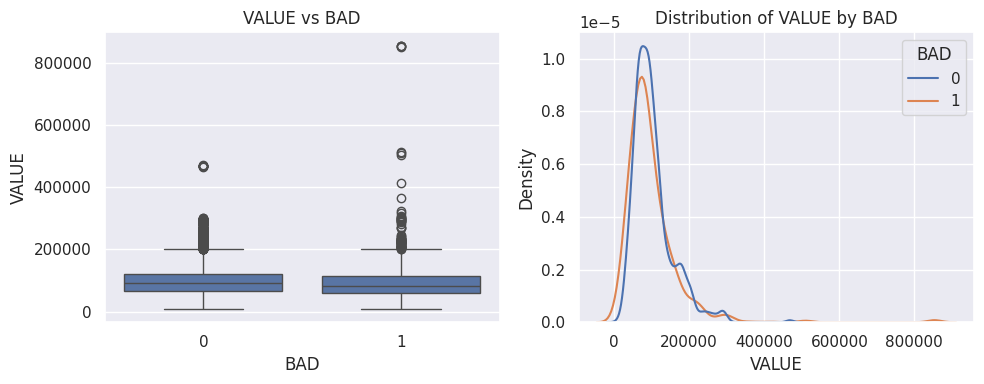

In [36]:
plot_numeric_vs_target(df, 'VALUE')

- The distributions of `VALUE` for defaulters and non-defaulters are highly overlapping, indicating minimal separation.
- Median property values are very similar across both groups, with only slight variation.
- Both classes exhibit strong right-skewness and large outliers, reflecting a wide range of property values.
- The KDE curves suggest that property value alone does not differentiate default behavior.

`VALUE` is a poor standalone predictor of default risk.

Its relevance is likely indirect and better captured through derived features.

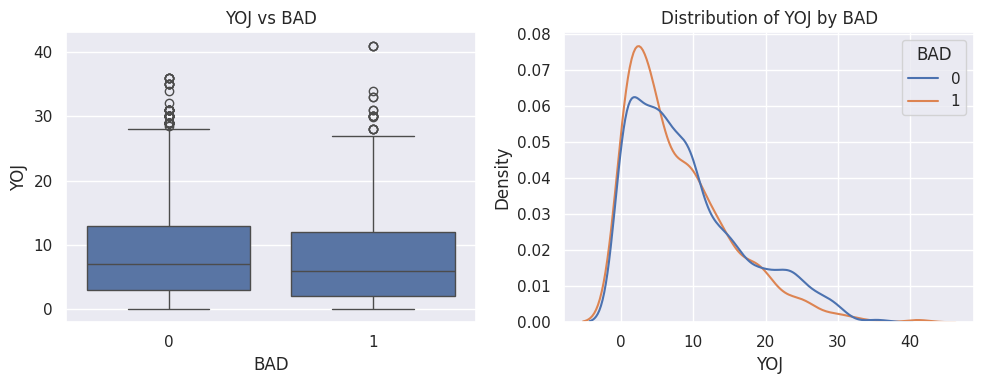

In [37]:
plot_numeric_vs_target(df, 'YOJ')

- Defaulters (`BAD = 1`) tend to have slightly lower years on the job (YOJ) compared to non-defaulters.
- The distribution for defaulters is more concentrated at lower YOJ values, indicating less job stability.
- While there is overlap, the separation is more visible than in LOAN, MORTDUE, or VALUE.

`YOJ` is a moderately informative predictor of default risk.

Lower job tenure is associated with higher likelihood of default, likely reflecting income instability.


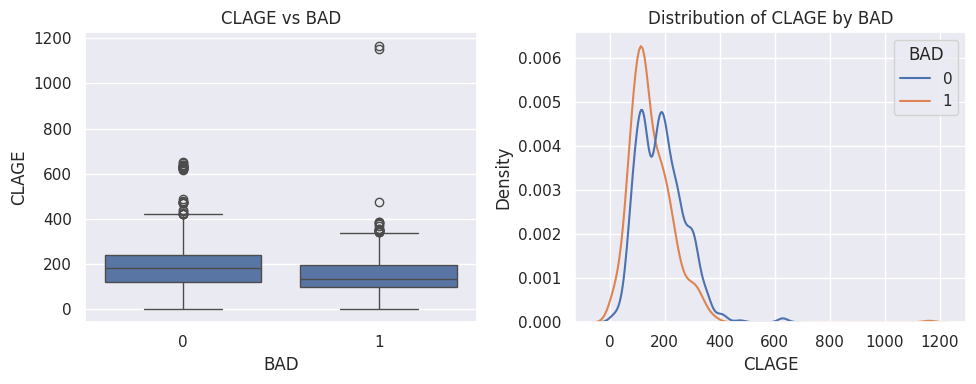

In [38]:
plot_numeric_vs_target(df, 'CLAGE')

- Defaulters (`BAD = 1`) tend to have lower credit age (CLAGE) compared to non-defaulters.
- The distribution for non-defaulters is shifted to the right, indicating longer credit histories.
- Defaulters show a left-shifted distribution, indicating shorter credit histories.
- There are some extreme outliers, but they do not change the overall pattern.

`CLAGE` is a useful predictor of default risk.

Longer credit history is associated with lower likelihood of default, likely reflecting more established and reliable credit behavior.

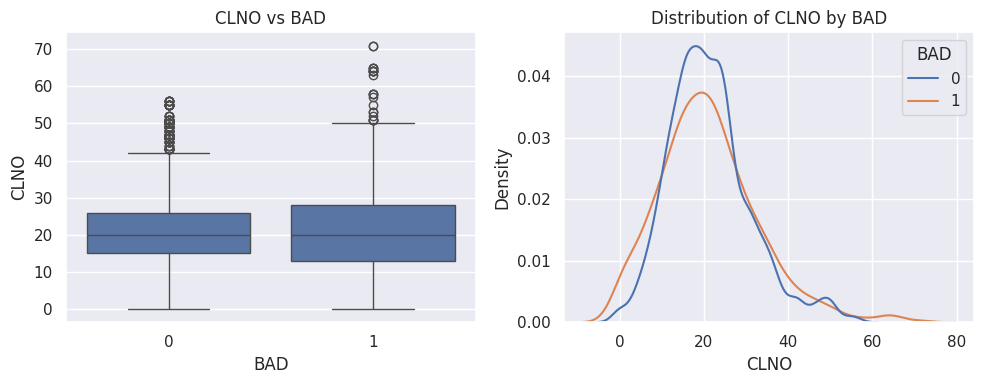

In [39]:
plot_numeric_vs_target(df, 'CLNO')

- Defaulters span both lower and higher credit line counts, indicating a non-linear relationship with risk.
- The distribution for defaulters is more spread out, with a heavier right tail, indicating higher credit exposure.
- Non-defaulters are more concentrated around moderate CLNO values, suggesting more controlled credit usage.
- There is still considerable overlap between the two groups.

`CLNO` is a moderately informative predictor of default risk but not strongly discriminative on its own.

Extreme values (low or high) may be associated with higher default risk.


In [40]:
def plot_discrete_vs_target(df, col, target='BAD'):
    plt.figure(figsize=(14, 4))

    # Count plot (VERY IMPORTANT for discrete features)
    plt.subplot(1, 2, 1)
    sns.countplot(data=df, x=col, hue=target)
    plt.title(f'Count of {col} by {target}')

    # KDE / histogram
    plt.subplot(1, 2, 2)
    sns.histplot(data=df, x=col, hue=target, bins=20, stat='density', common_norm=False)
    plt.title(f'Distribution of {col} by {target}')

    plt.tight_layout()
    plt.show()

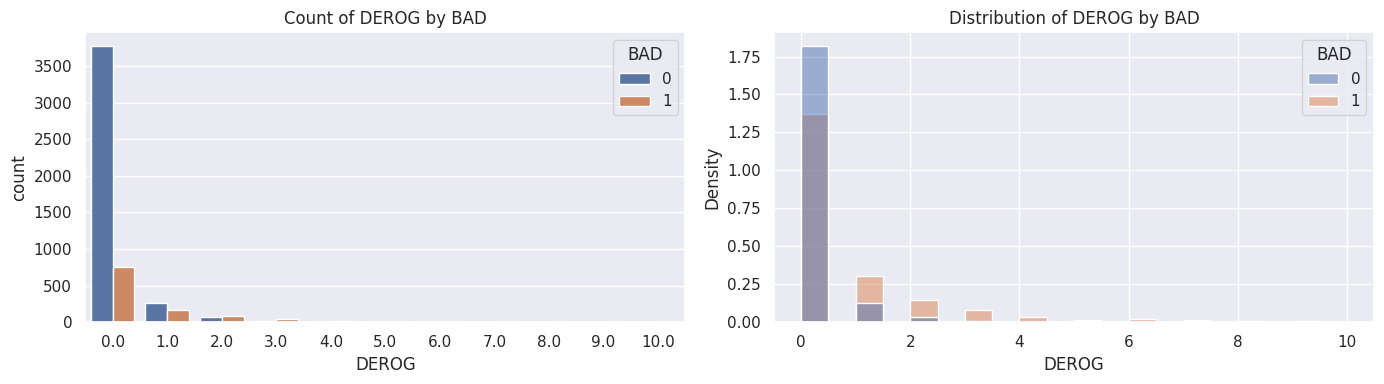

In [41]:
plot_discrete_vs_target(df, 'DEROG')

- The majority of observations are concentrated at DEROG = 0, especially for non-defaulters.
- Defaulters show a much heavier presence in DEROG ≥ 1, with visibly higher counts relative to non-defaulters.
- The distribution for defaulters has a longer right tail, extending to higher values of DEROG.
- Even small increases (e.g., from 0 → 1) correspond to a clear shift in class composition.

`DEROG` exhibits a strong threshold effect: moving from 0 to ≥1 significantly increases default risk.

This is one of the clearest and most interpretable predictors, directly reflecting past severe credit issues.

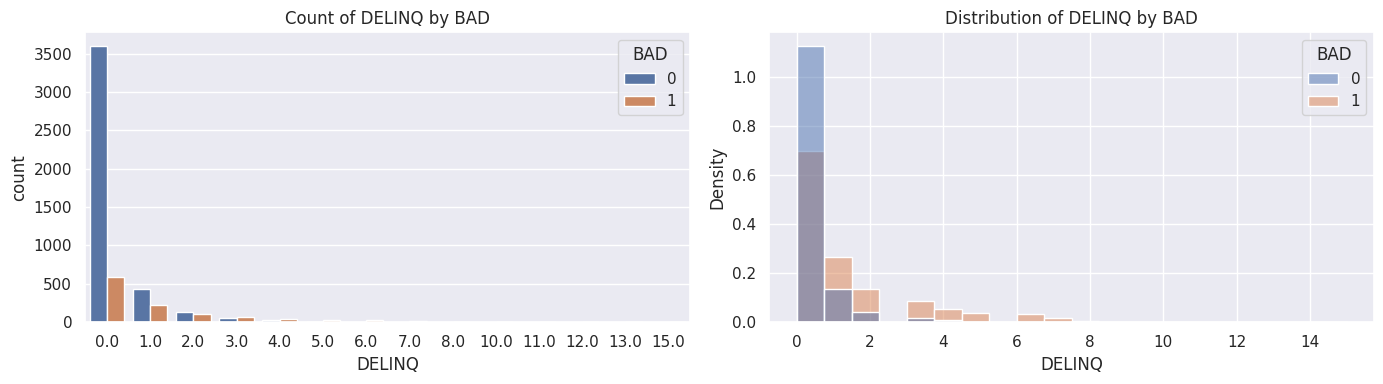

In [42]:
plot_discrete_vs_target(df, 'DELINQ')

- Most observations are concentrated at DELINQ = 0, especially for non-defaulters.
- Defaulters show a clear increase in frequency as DELINQ increases, with a heavier right tail.
- There is a noticaeble transition from 0 → 1.
- Higher values (≥2, ≥3) are increasingly dominated by defaulters, though these cases are relatively rare.

`DELINQ` shows a gradual risk increase.

It is a strong predictor, but more continuous in nature compared to DEROG.

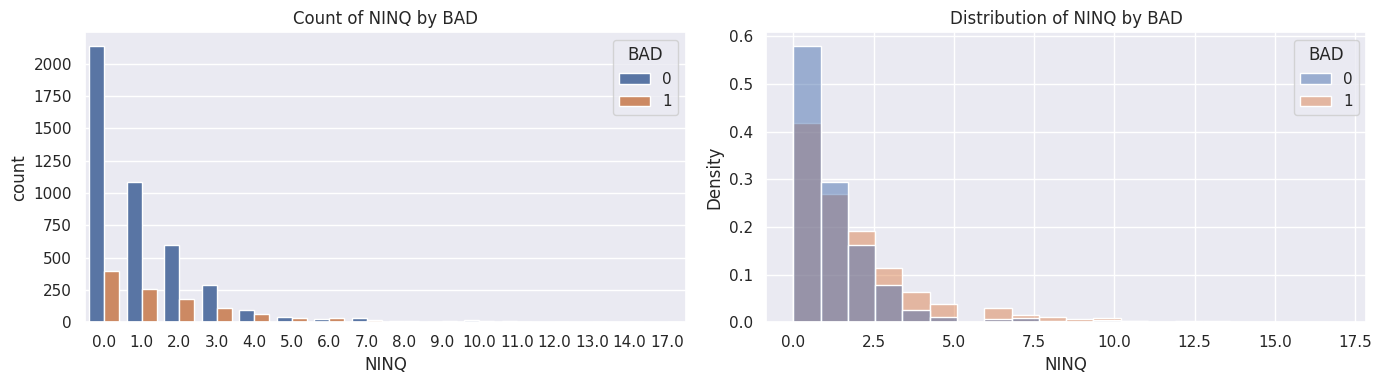

In [43]:
plot_discrete_vs_target(df, 'NINQ')

- Most observations are concentrated at low inquiry counts (0–2) for both defaulters and non-defaulters.
- Defaulters show a slightly heavier right tail, indicating more frequent higher inquiry counts.
- As `NINQ` increases, the relative presence of defaulters increases, but the separation remains modest.
- There is substantial overlap across all values, especially in the lower range.

`NINQ` exhibits a weak-to-moderate relationship with default risk.

Higher inquiry counts suggest increased credit-seeking behavior, but the signal is noisy and less discriminative compared to DEROG and DELINQ.

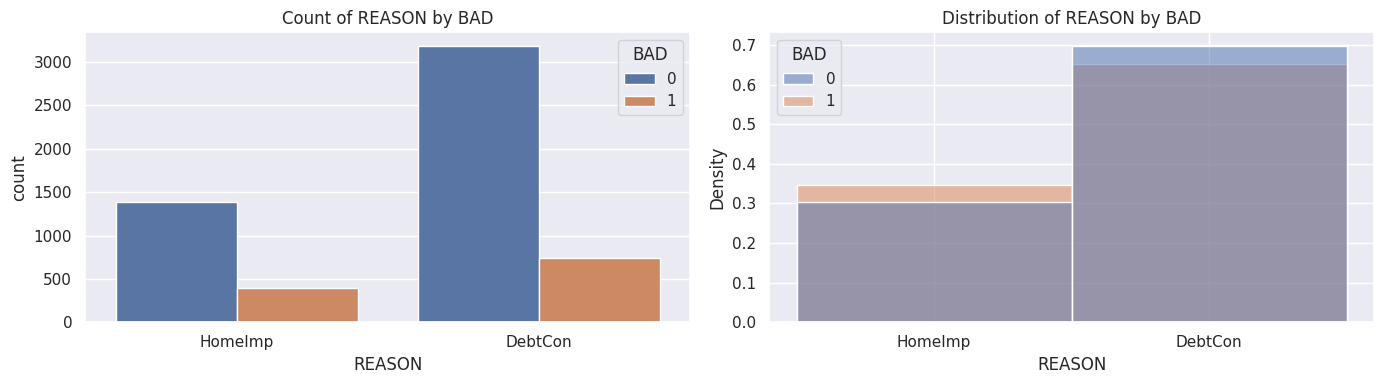

In [44]:
plot_discrete_vs_target(df, 'REASON')

- Both categories (`DebtCon` and `HomeImp`) contain defaulters, but DebtCon has a higher absolute number of defaults.
- This is partly driven by class imbalance, as `DebtCon` appears more frequently overall.
- The proportion of defaulters in `HomeImp` appears slightly higher relative to its total count.
- The difference between categories is not strongly pronounced, but some variation exists.

`REASON` has limited predictive power on its own, though it may contribute when combined with other features.

Loan purpose can provide contextual signals, but default risk is more strongly driven by financial and behavioral variables.

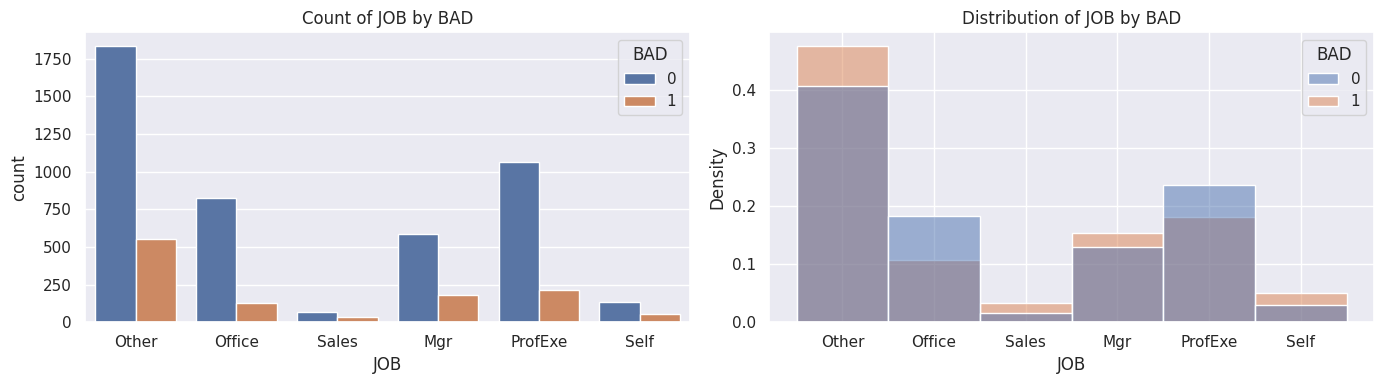

In [45]:
plot_discrete_vs_target(df, 'JOB')

- Default counts vary across job categories, with “Other” and “ProfExe” having the highest number of defaulters in absolute terms.
- However, these categories also have higher overall counts, indicating class imbalance.
- Some categories like “Sales” and “Self” show relatively higher default proportions compared to their total counts, despite smaller sample sizes.
- “Office” and “Mgr” roles appear more stable, with comparatively lower default proportions.

`JOB` provides useful segmentation signals, but its predictive strength depends on relative proportions rather than raw counts.

Certain job categories may reflect income stability and financial behavior, making this feature valuable when combined with others.

### **Multivariate Analysis**

In [46]:
def plot_correlation(df, cmap="coolwarm"):
    plt.figure(figsize=(10, 8))

    corr = df.corr(numeric_only=True)

    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5
    )

    plt.title("Correlation Matrix")
    plt.show()

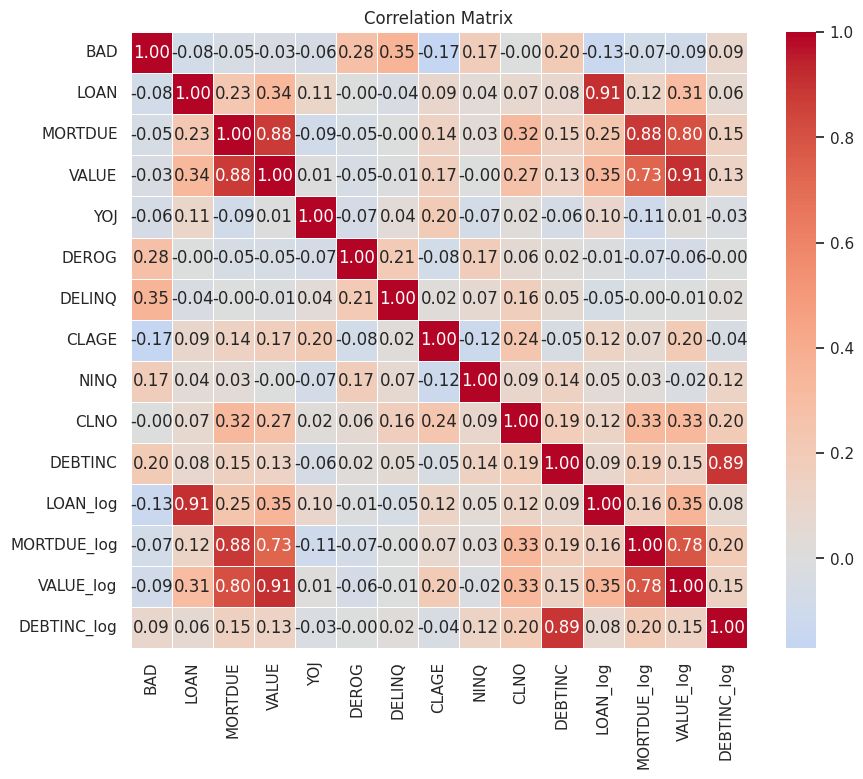

In [47]:
plot_correlation(df)

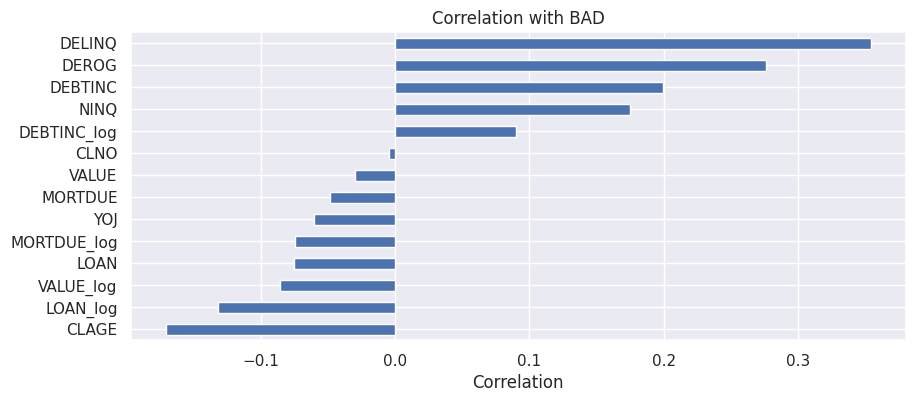

In [48]:
def plot_target_correlation(df, target):
    corr = df.corr(numeric_only=True)[target].sort_values()

    plt.figure(figsize=(10, 4))
    corr.drop(target).plot(kind='barh')
    plt.title(f'Correlation with {target}')
    plt.xlabel('Correlation')
    plt.show()

plot_target_correlation(df, 'BAD')

- Strongest positive correlations with BAD:
  - `DELINQ` (~0.35)
  - `DEROG` (~0.28)
  - `DEBTINC` (~0.20)
  - `NINQ` (~0.17)

- Weak or negligible correlations:
  - `LOAN`, `MORTDUE`, `VALUE`, `CLNO` (near 0)

- Negative correlations:
  - `CLAGE` (~-0.17)
  - `YOJ` (~-0.06)

- High multicollinearity:
  - `MORTDUE` ↔ `VALUE` (~0.88)

Default risk is driven primarily by credit behavior (DELINQ, DEROG) and financial stress (DEBTINC).

Asset-related variables (LOAN, VALUE, MORTDUE) have little direct predictive power.

CLAGE confirms stability effect (longer credit history → lower risk).


## Treating Missing Values

**DEBTINC Variable**

In [49]:
def missing_vs_target(df, col, target='BAD'):
    df_temp = df.copy()
    df_temp[col + '_missing'] = df_temp[col].isnull().astype(int)

    # Plot
    sns.countplot(data=df_temp, x=col + '_missing', hue=target)
    plt.title(f'Missing Indicator for {col} vs {target}')
    plt.xlabel('0 = Present, 1 = Missing')
    plt.show()

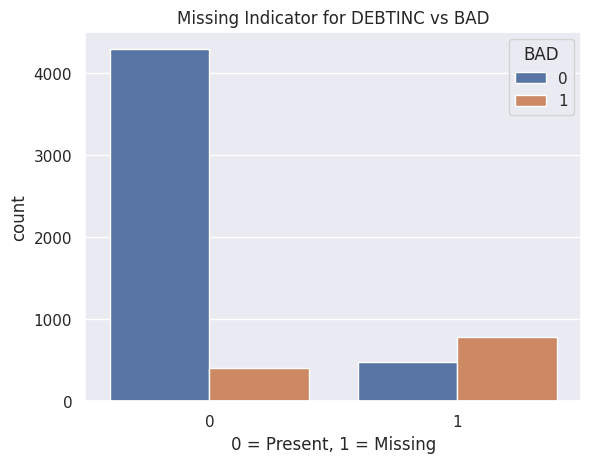

In [50]:
missing_vs_target(df, 'DEBTINC')

- When `DEBTINC` is present (0):
  - Majority are non-defaulters
- When `DEBTINC` is missing (1):
  - Defaulters significantly increase

- The proportion of `BAD = 1` is much higher in the missing group

Missing `DEBTINC` is informative, and ay not be random. It is strongly associated with higher default risk.


In [51]:
# Keeping the missingness as a feature
df['DEBTINC_missing'] = df['DEBTINC'].isnull().astype(int)

In [52]:
# Imputing missing values with the median
df['DEBTINC'] = df['DEBTINC'].fillna(df['DEBTINC'].median())

# Log transform
df['DEBTINC_log'] = np.log1p(df['DEBTINC'])

**DEROG Variable**

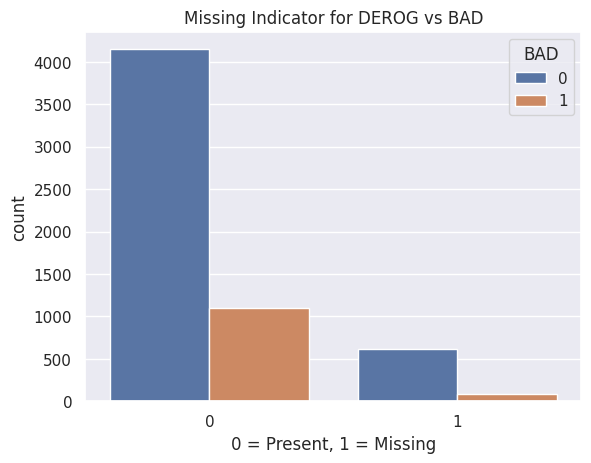

In [53]:
missing_vs_target(df, 'DEROG')

- Missing `DEROG` does not indicate higher risk
- Missingness appears non-informative or even slightly associated with lower risk

In [54]:
# Imputing missing values with 0 (assume no derogatory history)
df['DEROG'] = df['DEROG'].fillna(0)

Since default risk increases significantly when `DEROG` > 0, we will create a binary flag indicating presence of any derogatory credit history.

In [55]:
# Create binary flag for presence of any derogatory history
df['DEROG_flag'] = (df['DEROG'] > 0).astype(int)

**DELINQ Variable**

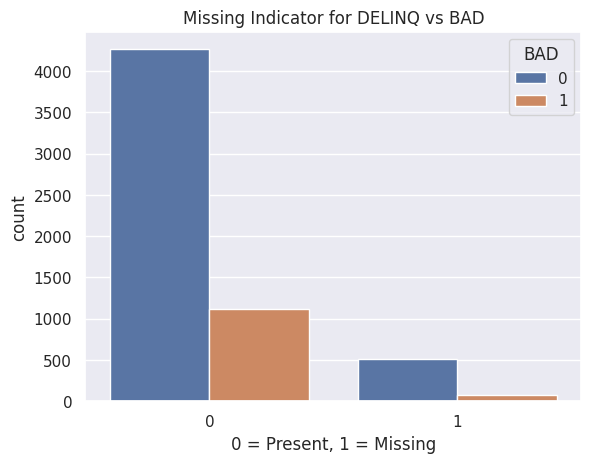

In [56]:
missing_vs_target(df, 'DELINQ')

- Missing DELINQ is not associated with higher risk.
- Likely non-informative missingness.

In [57]:
# Imputing missing values with 0 (assume no delinquency history)
df['DELINQ'] = df['DELINQ'].fillna(0)

In [58]:
# Create binary flag for presence of any delinquency history
df['DELINQ_flag'] = (df['DELINQ'] > 0).astype(int)

**MORTDUE Variable**

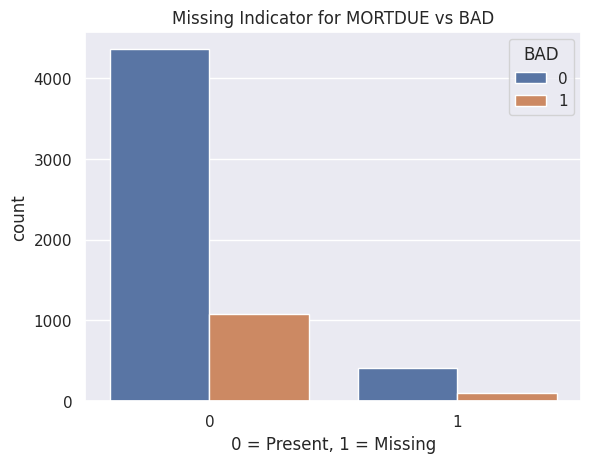

In [59]:
missing_vs_target(df, 'MORTDUE')

- Missing `MORTDUE` is not strongly predictive of default.
- Likely reflects absence of mortgage or unavailable reporting.


In [60]:
# Imputing missing mortgage balance with median
df['MORTDUE'] = df['MORTDUE'].fillna(df['MORTDUE'].median())

# Log transform
df['MORTDUE_log'] = np.log1p(df['MORTDUE'])

**YOJ Variable**

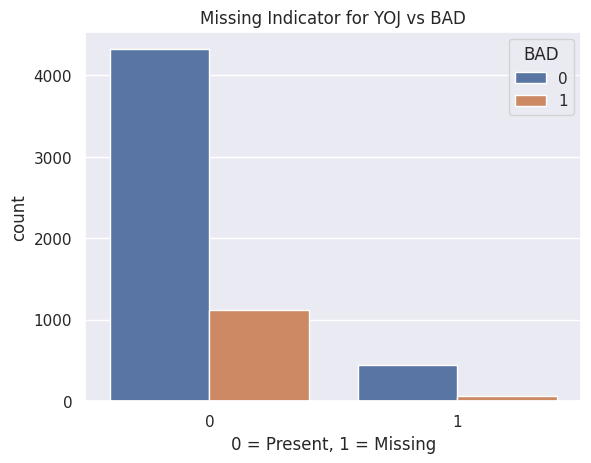

In [61]:
missing_vs_target(df, 'YOJ')

- Missing `YOJ` is not strongly predictive of default.
- Likely reflects unreported employment duration rather than risk signal.

In [62]:
# Imputing missing YOJ with median
df['YOJ'] = df['YOJ'].fillna(df['YOJ'].median())

**NINQ Variable**

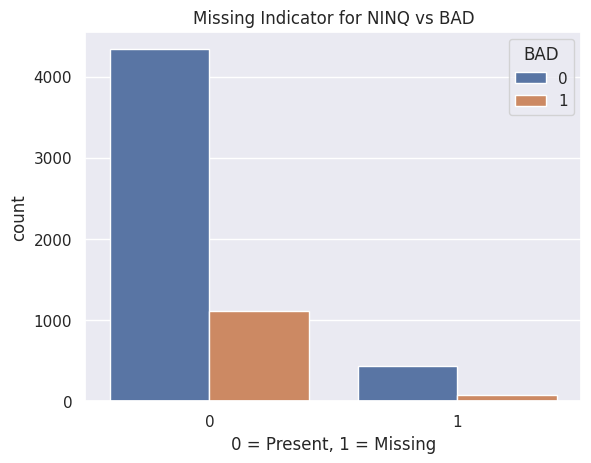

In [63]:
missing_vs_target(df, 'NINQ')

- Missing `NINQ` is not strongly associated with higher default risk.
- Likely reflects absence of recorded credit inquiries or incomplete reporting.

Although missing values may represent either unreported data or absence of credit inquiries, the observed distribution of `NINQ` is heavily concentrated at low values, particularly 0.

Therefore, we will impute the missing values with 0.

In [64]:
# Imputing missing inquiry counts with 0 (assume no recent credit inquiries)
df['NINQ'] = df['NINQ'].fillna(0)

**CLAGE Variable**

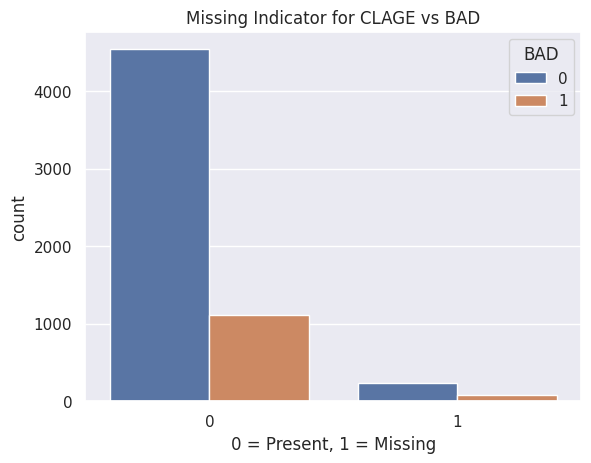

In [65]:
missing_vs_target(df, 'CLAGE')

- Missing `CLAGE` likely reflects unavailable credit history length rather than risk signal.

In [66]:
# Imputing missing CLAGE with median
df['CLAGE'] = df['CLAGE'].fillna(df['CLAGE'].median())

**Job Variable**

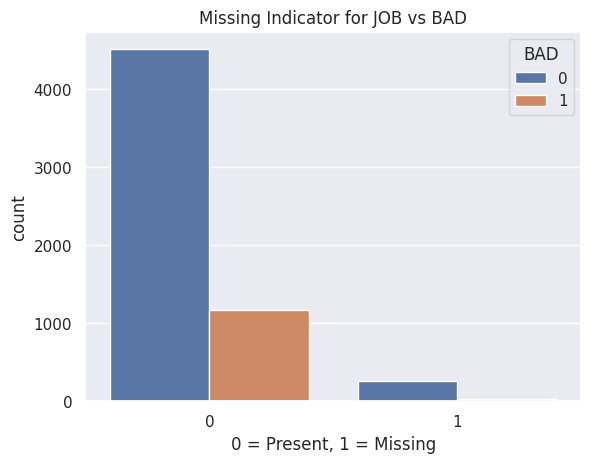

In [67]:
missing_vs_target(df, 'JOB')

- Missing `JOB` likely reflects unreported employment category rather than a risk signal.

In [68]:
# Treating missing job as its own category
df['JOB'] = df['JOB'].fillna('Missing')

In [69]:
df['JOB'].value_counts()

,count
JOB,
Other,2388
ProfExe,1276
Office,948
Mgr,767
Missing,279
Self,193
Sales,109


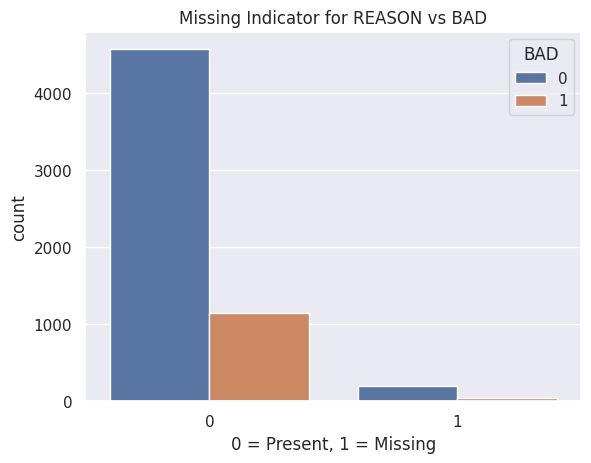

In [70]:
missing_vs_target(df, 'REASON')

- Missing `REASON` likely reflects unreported loan purpose rather than a risk signal.

In [71]:
# Treating missing loan purpose as its own category
df['REASON'] = df['REASON'].fillna('Missing')

In [72]:
df['REASON'].value_counts()

,count
REASON,
DebtCon,3928
HomeImp,1780
Missing,252


**CLNO Variable**

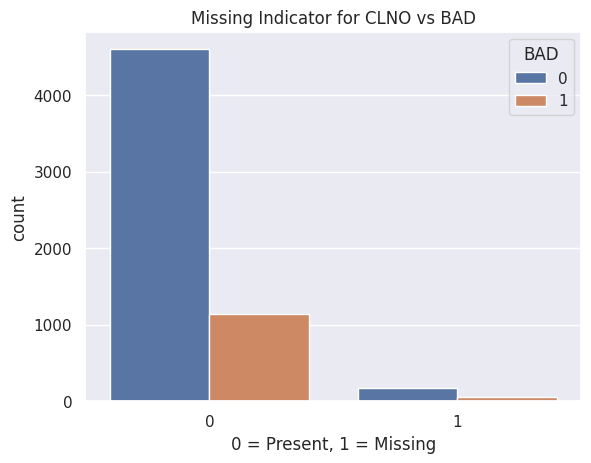

In [73]:
missing_vs_target(df, 'CLNO')

- Missing `CLNO` likely reflects absence of reported credit lines or incomplete reporting.

In [74]:
df['CLNO'] = df['CLNO'].fillna(df['CLNO'].median())

**VALUE Variable**

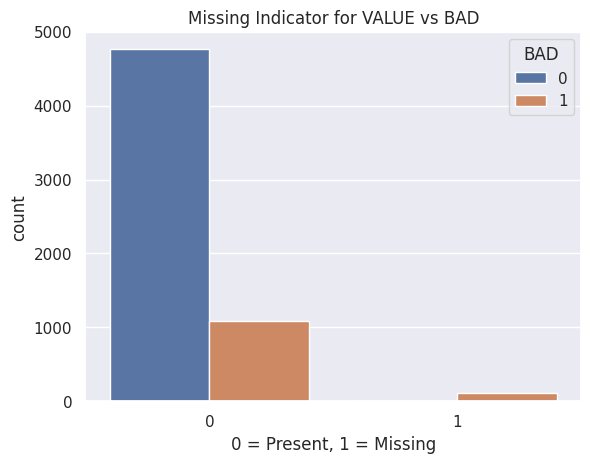

In [75]:
missing_vs_target(df, 'VALUE')

- Missing `VALUE` is highly predictive of default. It is a strong risk signal.


In [76]:
# Keeping the missingness as a feature
df['VALUE_missing'] = df['VALUE'].isnull().astype(int)

In [77]:
# Imputing missing property values with median
df['VALUE'] = df['VALUE'].fillna(df['VALUE'].median())

# Log transform
df['VALUE_log'] = np.log1p(df['VALUE'])

## Treating Outliers

Outliers are extreme values that can disproportionately influence model behavior, particularly in skewed distributions.

Instead of removing observations, outliers are treated using capping (winsorization):
- Values below the 1st percentile are set to the 1st percentile
- Values above the 99th percentile are set to the 99th percentile

This approach:
- preserves all observations
- reduces the impact of extreme values
- improves model stability

Outlier treatment is applied selectively based on feature type and distribution characteristics.

In [78]:
cols_to_cap = ['DEBTINC', 'MORTDUE', 'VALUE', 'CLAGE']

cap_dict = {}

for col in cols_to_cap:
    upper = df[col].quantile(0.99)
    cap_dict[col] = upper

    df[f'{col}_capped'] = df[col].clip(upper=upper)

## Default Rate Analysis


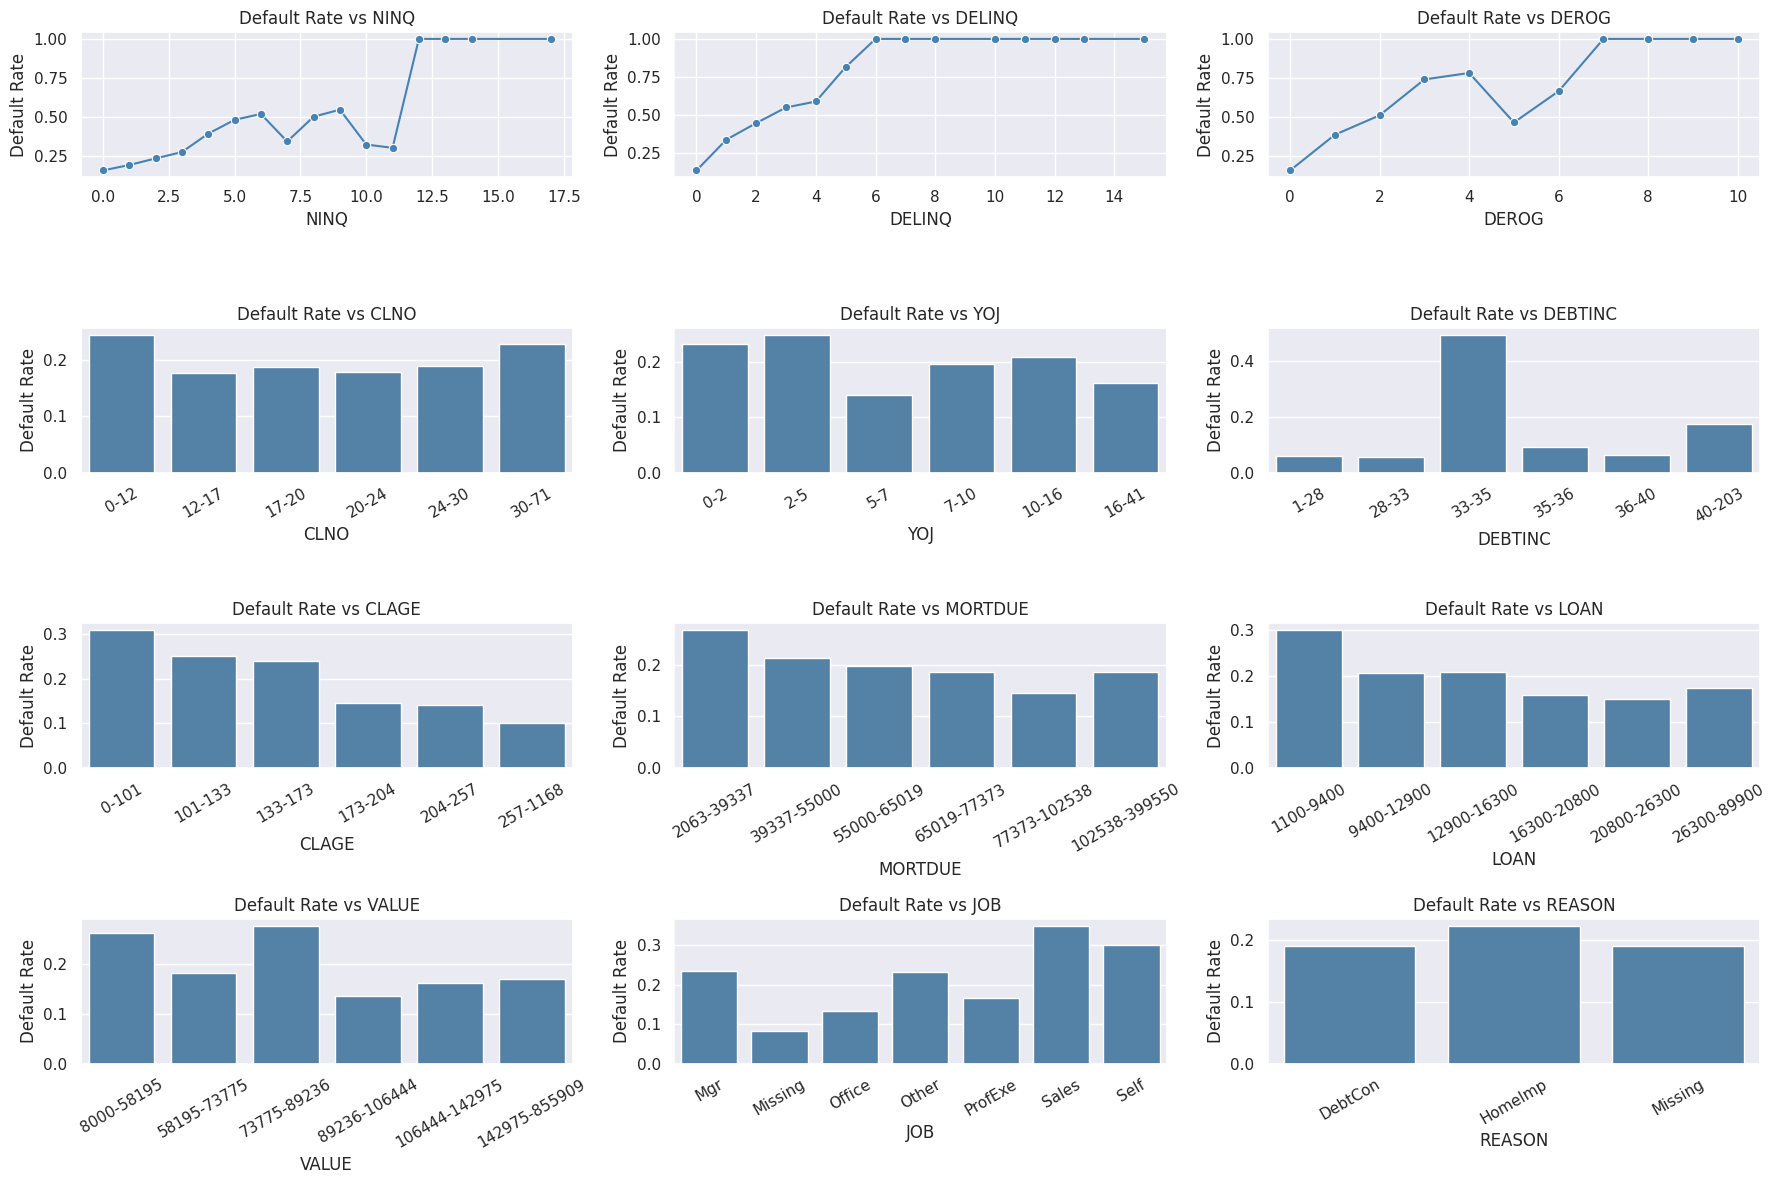

In [79]:
fig, axes = plt.subplots(4, 3, figsize=(18, 12))
axes = axes.flatten()

# ----------------NINQ ----------------
ninq_default = df.groupby('NINQ', as_index=False)['BAD'].mean()
sns.lineplot(data=ninq_default, x='NINQ', y='BAD', marker='o', ax=axes[0], color='steelblue')
axes[0].set_title('Default Rate vs NINQ')
axes[0].set_xlabel('NINQ')
axes[0].set_ylabel('Default Rate')

# ----------------DELINQ ----------------
delinq_default = df.groupby('DELINQ', as_index=False)['BAD'].mean()
sns.lineplot(data=delinq_default, x='DELINQ', y='BAD', marker='o', ax=axes[1], color='steelblue')
axes[1].set_title('Default Rate vs DELINQ')
axes[1].set_xlabel('DELINQ')
axes[1].set_ylabel('Default Rate')

# ----------------DEROG ----------------
derog_default = df.groupby('DEROG', as_index=False)['BAD'].mean()
sns.lineplot(data=derog_default, x='DEROG', y='BAD', marker='o', ax=axes[2], color='steelblue')
axes[2].set_title('Default Rate vs DEROG')
axes[2].set_xlabel('DEROG')
axes[2].set_ylabel('Default Rate')

# Function for binning
def create_binned_plot(df, col, ax, title):
    df[f'{col}_bin'] = pd.qcut(df[col], q=6, duplicates='drop')
    temp = df.groupby(f'{col}_bin', observed=False)['BAD'].mean().reset_index()
    temp['label'] = [f"{round(i.left)}-{round(i.right)}" for i in temp[f'{col}_bin']]

    sns.barplot(data=temp, x='label', y='BAD', ax=ax, color='steelblue')
    ax.set_title(f'Default Rate vs {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Default Rate')
    ax.tick_params(axis='x', rotation=30)

# ----------------Binned variables ----------------
create_binned_plot(df, 'CLNO', axes[3], 'CLNO')
create_binned_plot(df, 'YOJ', axes[4], 'YOJ')
create_binned_plot(df, 'DEBTINC', axes[5], 'DEBTINC')
create_binned_plot(df, 'CLAGE', axes[6], 'CLAGE')
create_binned_plot(df, 'MORTDUE', axes[7], 'MORTDUE')
create_binned_plot(df, 'LOAN', axes[8], 'LOAN')
create_binned_plot(df, 'VALUE', axes[9], 'VALUE')

# ----------------JOB ----------------
job_default = df.groupby('JOB', observed=False)['BAD'].mean().reset_index()
sns.barplot(data=job_default, x='JOB', y='BAD', ax=axes[10], color='steelblue')
axes[10].set_title('Default Rate vs JOB')
axes[10].set_xlabel('JOB')
axes[10].set_ylabel('Default Rate')
axes[10].tick_params(axis='x', rotation=30)

# ----------------REASON ----------------
reason_default = df.groupby('REASON', observed=False)['BAD'].mean().reset_index()
sns.barplot(data=reason_default, x='REASON', y='BAD', ax=axes[11], color='steelblue')
axes[11].set_title('Default Rate vs REASON')
axes[11].set_xlabel('REASON')
axes[11].set_ylabel('Default Rate')
axes[11].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

- Strong monotonic risk signals (behavioral variables)
  - Default rate increases sharply with higher values of `NINQ`, `DELINQ`, and `DEROG`.
  - Borrowers with multiple delinquencies or derogatory records show near-certain default at higher levels.

- Debt burden is a key driver
  - `DEBTINC` shows a clear spike in default at higher ratios, indicating financial strain as a major risk factor.
  - Higher `LOAN` and `MORTDUE` amounts are associated with moderately elevated default risk.

- Credit history length reduces risk
  - `CLAGE` shows a decreasing trend, suggesting longer credit history is associated with lower default probability.
  - `CLNO` shows relatively stable behavior, with slight increases at extreme values.

- Nonlinear effects in employment duration
  - `YOJ` does not show a strictly monotonic pattern, indicating weaker predictive power or interaction effects.

- Collateral value and loan purpose
  - `VALUE` shows some variation, but no strong monotonic relationship with default.
  - `REASON` indicates slightly higher default for Home Improvement loans compared to Debt Consolidation.

- Occupation-based risk differences
  - `JOB` shows clear segmentation:
    - Higher risk: Sales, Self-employed
    - Lower risk: Professional
  - This suggests income stability plays a role in default behavior.

Overall, default risk is most strongly driven by credit behavior and financial stress, while other variables exhibit weaker or nonlinear relationships.

## **Important Insights from EDA**



## **Model Building - Approach**
- Data preparation
- Partition the data into train and test set
- Build the model
- Fit on the train data
- Tune the model
- Test the model on test set

**Data Preparation**

In [127]:
model_df = df.copy()

# Drop binned columns (EDA only)
cols_to_drop = ["DEBTINC_bin", "CLAGE_bin", "VALUE_bin", "CLNO_bin", "YOJ_bin", "MORTDUE_bin", "LOAN_bin"]
model_df = model_df.drop(columns=cols_to_drop, errors="ignore")

In [128]:
# Target
y = model_df["BAD"]

# Features (original)
X = model_df.drop(columns=["BAD"])

In [129]:
# Create dummy variables for the categorical variables
X = pd.get_dummies(X, columns=["REASON", "JOB"], drop_first=True)

**Partitioning the data into train and test set**


In [130]:
# Split original data
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=1, stratify=y)

#### **Model Evaluation Criteria**

Since this is a loan default prediction problem, the primary concern is correctly identifying applicants who are likely to default.

#### **Key Considerations**
- A False Negative (predicting non-default when the applicant actually defaults) is more costly, as it leads to financial loss for the bank.
- A False Positive (predicting default when the applicant would repay) results in opportunity loss but is less severe than a default.

---

**Evaluation Metrics**

To capture this trade-off, the following metrics will be used:

- **Recall (Sensitivity) for BAD = 1**
  - Measures how many actual defaulters are correctly identified
  - This is the most important metric in this problem

- **Precision**
  - Ensures that predicted defaulters are actually high-risk
  - Helps avoid rejecting too many good customers

- **F1-Score**
  - Balances precision and recall
  - Useful when there is class imbalance

- **ROC-AUC**
  - Measures overall model discrimination ability across thresholds

In [131]:
def metrics_score(actual, predicted, predicted_proba=None):
    print("Classification Report:\n")
    print(classification_report(actual, predicted))

    scores = {
        "Accuracy": accuracy_score(actual, predicted),
        "Precision": precision_score(actual, predicted),
        "Recall": recall_score(actual, predicted),
        "F1 Score": f1_score(actual, predicted)
    }

    if predicted_proba is not None:
        scores["ROC-AUC"] = roc_auc_score(actual, predicted_proba)

    # Confusion matrix
    cm = confusion_matrix(actual, predicted)

    # Row-wise normalization
    cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    # Annotate both raw counts and normalized values
    annot_labels = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot_labels[i, j] = f"{cm[i, j]}\n({cm_normalized[i, j]:.2f})"

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm_normalized,
        annot=annot_labels,
        fmt="",
        cmap="Blues",
        xticklabels=["Non-Default (0)", "Default (1)"],
        yticklabels=["Non-Default (0)", "Default (1)"]
    )
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.title("Confusion Matrix")
    plt.show()

    print(f"Metric Summary:\n","-"*12)
    for metric, value in scores.items():
        print(f"{metric}: {value:.4f}")

### Logistic Regression

In [133]:
scaler = StandardScaler()

# Original dataset
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### **Baseline Model**

In [134]:
# Initialize model
lr = LogisticRegression(random_state=1, max_iter=1000)

# Fit model
lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=1)

### Predictions

In [135]:
# Train predictions
lr_pred_train = lr.predict(X_train_scaled)
lr_pred_train_prob = lr.predict_proba(X_train_scaled)[:, 1]

# Test predictions
lr_pred_test = lr.predict(X_test_scaled)
lr_pred_test_prob = lr.predict_proba(X_test_scaled)[:, 1]

### Evaluation

-------------------- 
Train Performance:
 --------------------
Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      3340
           1       0.80      0.64      0.72       832

    accuracy                           0.90      4172
   macro avg       0.86      0.80      0.83      4172
weighted avg       0.89      0.90      0.89      4172



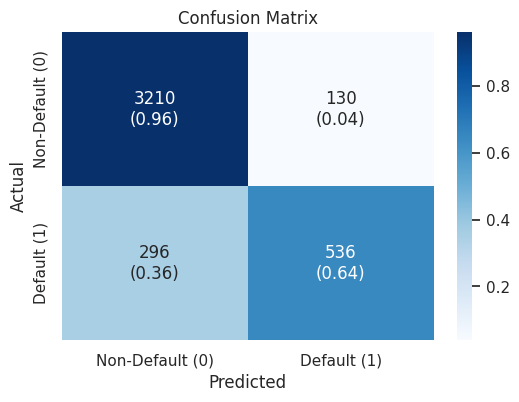

Metric Summary:
 ------------
Accuracy: 0.8979
Precision: 0.8048
Recall: 0.6442
F1 Score: 0.7156
ROC-AUC: 0.9163


In [136]:
print(f"-"*20, "\nTrain Performance:\n","-"*20)

metrics_score(y_train, lr_pred_train, lr_pred_train_prob)

-------------------- 
Test Performance:
 --------------------
Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.96      0.93      1431
           1       0.80      0.59      0.68       357

    accuracy                           0.89      1788
   macro avg       0.85      0.78      0.81      1788
weighted avg       0.88      0.89      0.88      1788



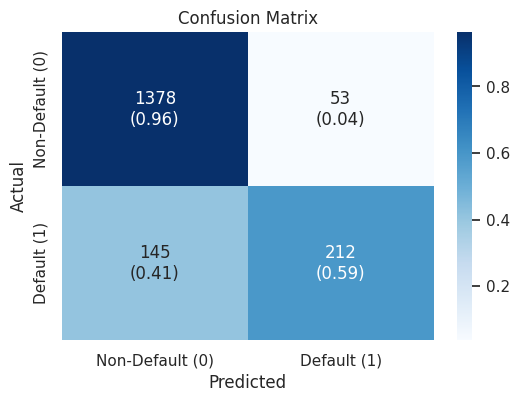

Metric Summary:
 ------------
Accuracy: 0.8893
Precision: 0.8000
Recall: 0.5938
F1 Score: 0.6817
ROC-AUC: 0.9049


In [137]:
print(f"-"*20, "\nTest Performance:\n", "-"*20)

metrics_score(y_test, lr_pred_test, lr_pred_test_prob)

- The model shows good overall performance with ~89% accuracy on both train and test sets, indicating stable generalization.
- No significant overfitting is observed, as train and test metrics are close across all measures.
- The model performs very well on non-defaults (class 0) with high recall (~96%), meaning most safe applicants are correctly identified.
- However, recall for defaulters (class 1) is moderate (~59%), meaning a substantial portion of risky applicants are still missed.
- Precision for defaulters (~80%) is relatively high, indicating that when the model predicts default, it is usually correct.
- The ROC-AUC (~0.90) suggests strong overall discrimination capability between defaulters and non-defaulters.

The lower recall for defaulters is likely influenced by class imbalance, where the model is biased toward predicting the majority class (non-default).

In general, the model is conservative in predicting defaults (high precision, lower recall), which reduces false alarms but misses some high-risk applicants.
- This trade-off may not be optimal for a banking context where detecting defaulters is more critical.

---------------------------------------- 
Test Performance at threshold = 0.35 
 ----------------------------------------
Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      1431
           1       0.72      0.71      0.71       357

    accuracy                           0.89      1788
   macro avg       0.82      0.82      0.82      1788
weighted avg       0.89      0.89      0.89      1788



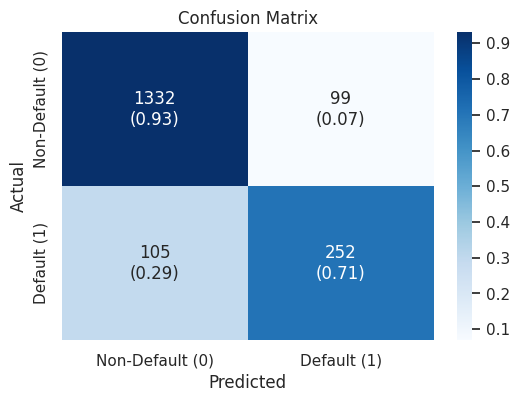

Metric Summary:
 ------------
Accuracy: 0.8859
Precision: 0.7179
Recall: 0.7059
F1 Score: 0.7119
ROC-AUC: 0.9049


In [138]:
threshold = 0.35

# Apply threshold
lr_pred_test_thresh = (lr_pred_test_prob >= threshold).astype(int)

# Evaluate
print(f"-"*40, "\nTest Performance at threshold =", threshold, "\n", "-"*40)
metrics_score(y_test, lr_pred_test_thresh, lr_pred_test_prob)

- Lowering the threshold significantly improved recall for defaulters from ~59% → ~71%, meaning the model now captures more high-risk applicants.
- This comes with a drop in precision (from ~80% → ~72%), indicating more false positives (some good applicants flagged as risky).
- F1-score improved (~0.68 → ~0.71), showing a better balance between precision and recall.
- Accuracy remains stable (~89%), indicating no major degradation in overall performance.
- ROC-AUC remains unchanged (~0.90), as expected, since it is threshold-independent.

Adjusting the threshold leads to a better trade-off for this problem, prioritizing detection of defaulters.

The model becomes less conservative and more risk-sensitive, which is more aligned with the banking objective.

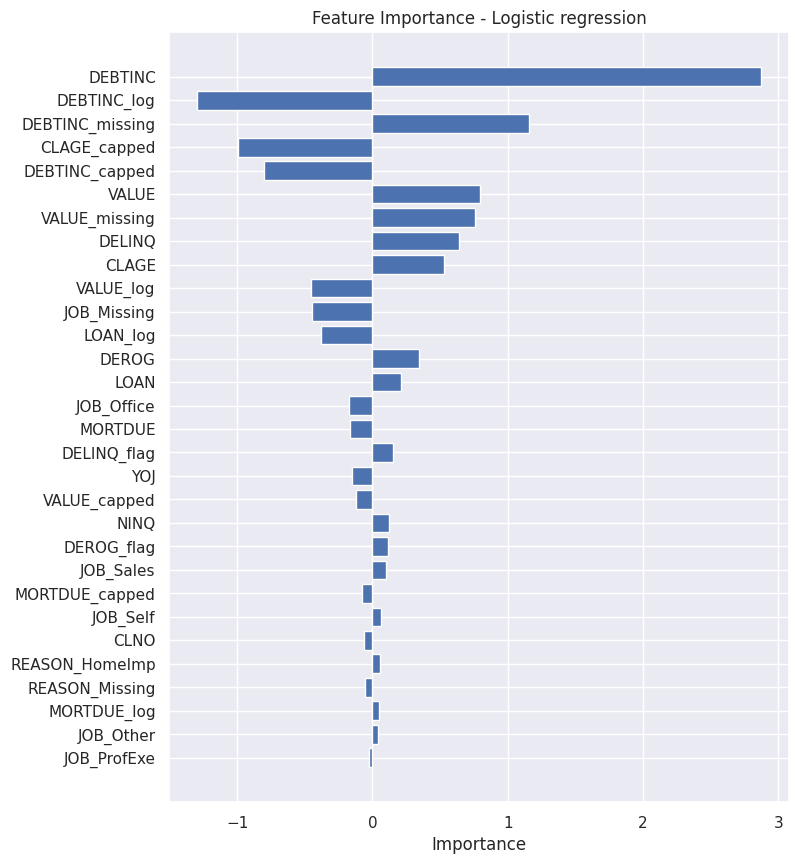

In [152]:
coefficients = lr.coef_[0]
features = X_train.columns

# DataFrame
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients
})

# Sort by absolute importance
coef_df["Abs_Coeff"] = np.abs(coef_df["Coefficient"])
coef_df = coef_df.sort_values(by="Abs_Coeff", ascending=False)

plt.figure(figsize=(8, 10))
plt.barh(coef_df["Feature"], coef_df["Coefficient"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Logistic regression")
plt.xlabel("Importance")
plt.show()

Debt-to-income ratio is the strongest predictor of default. Higher values significantly increase the likelihood of default, indicating that borrowers with heavier debt burdens are at higher risk.

Additionally, missing debt-to-income information is itself associated with increased default risk, suggesting incomplete financial profiles may signal instability.

### Decision Tree

Decision trees are capable of capturing non-linear relationships and feature interactions that logistic regression may miss. They are also inherently interpretable, making them suitable for credit risk applications where understanding decision rules is important.

### Baseline Model

In [96]:
# Initialize model
dt = DecisionTreeClassifier(random_state=1)

# Fit model
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

### Predictions

In [97]:
# Train predictions
dt_pred_train = dt.predict(X_train)
dt_pred_train_prob = dt.predict_proba(X_train)[:, 1]

# Test predictions
dt_pred_test = dt.predict(X_test)
dt_pred_test_prob = dt.predict_proba(X_test)[:, 1]

### Evaluation

-------------------- 
Train Performance:
 --------------------
Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3340
           1       1.00      1.00      1.00       832

    accuracy                           1.00      4172
   macro avg       1.00      1.00      1.00      4172
weighted avg       1.00      1.00      1.00      4172



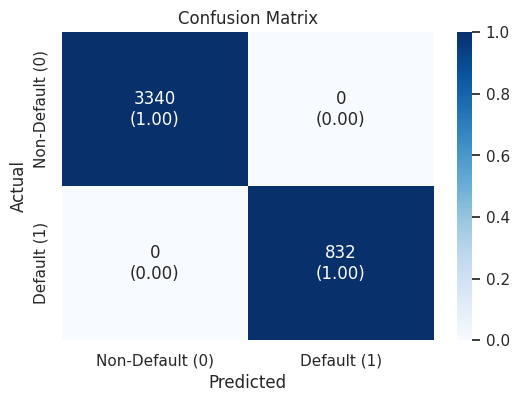

Metric Summary:
 ------------
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
ROC-AUC: 1.0000


In [98]:
print(f"-"*20, "\nTrain Performance:\n", "-"*20)
dt_train_scores = metrics_score(y_train, dt_pred_train, dt_pred_train_prob)

-------------------- 
Test Performance:
 --------------------
Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.94      0.93      1431
           1       0.73      0.68      0.70       357

    accuracy                           0.89      1788
   macro avg       0.83      0.81      0.82      1788
weighted avg       0.88      0.89      0.88      1788



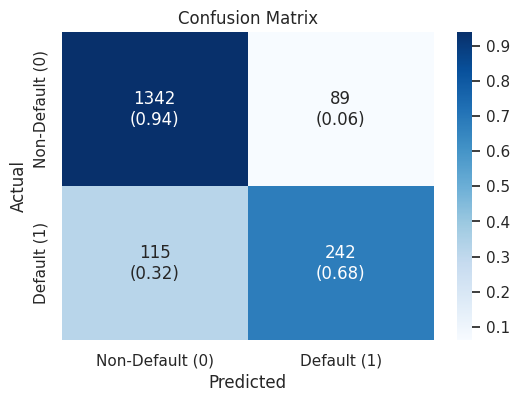

Metric Summary:
 ------------
Accuracy: 0.8859
Precision: 0.7311
Recall: 0.6779
F1 Score: 0.7035
ROC-AUC: 0.8078


In [99]:
print(f"-"*20, "\nTest Performance:\n", "-"*20)
dt_test_scores = metrics_score(y_test, dt_pred_test, dt_pred_test_prob)

- The model achieves perfect performance on training data (100%), with a clear drop in performance on test data (88%), showing that the model does not generalize well, and indicating severe overfitting.

- Compared to logistic regression (threshold = 0.35):
  - Recall for defaulters is slightly lower (~68% vs ~71%), meaning the tuned logistic model still misses more risky applicants.
  - Precision is slightly higher (~73% vs ~72%), indicating fewer false positives.
  - F1-score is slightly lower, showing a weaker balance overall.
  - ROC-AUC is significantly lower (~0.81 vs ~0.90), indicating poorer overall ranking ability.

Despite capturing non-linear patterns, the baseline decision tree overfits heavily and underperforms the tuned logistic regression.

Logistic regression with threshold tuning remains more reliable and better balanced at this stage.

The decision tree requires pruning/tuning to reduce overfitting and improve generalization.

### **Decision Tree - Hyperparameter Tuning**


- Since there is no direct way to calculate how a change in the hyperparameter value will reduce the loss of the model, we will resort to experimentation using Grid search to perform hyperparameter tuning.
- Grid search is a tuning technique that attempts to compute the optimum values of hyperparameters.
- It is an exhaustive search that is performed on the specific parameter values of a model.
- The parameters of the estimator/model used to apply these methods are optimized by cross-validated grid-search over a parameter grid.

**Criterion {“gini”, “entropy”}**

- The function to measure the quality of a split. Supported criteria are “gini” for the Gini impurity and “entropy” for the information gain.

**max_depth**

- The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.

**min_samples_leaf**

- The minimum number of samples is required to be at a leaf node. A split point at any depth will only be considered if it leaves at least min_samples_leaf training samples in each of the left and right branches. This may have the effect of smoothing the model, especially in regression.

This helps produce a model that generalizes better to unseen data while retaining the tree’s ability to capture non-linear relationships.

In [100]:
# Base model
dtree = DecisionTreeClassifier(random_state=1)

# Parameter grid
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [10, 12, 14, 16],
    "min_samples_leaf": [2, 3, 4, 5]
}

# Grid search
grid_search_dtree = GridSearchCV(
    estimator=dtree,
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

# Fit
grid_search_dtree.fit(X_train, y_train)

# Best model
dtree_tuned = grid_search_dtree.best_estimator_

print("Best Parameters:", grid_search_dtree.best_params_)
print("Best CV Score:", grid_search_dtree.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 12}
Best CV Score: 0.6827068754058149


### **Model Evaluation**

In [101]:
# Train predictions
dtree_tuned_pred_train = dtree_tuned.predict(X_train)
dtree_tuned_pred_train_prob = dtree_tuned.predict_proba(X_train)[:, 1]

# Test predictions
dtree_tuned_pred_test = dtree_tuned.predict(X_test)
dtree_tuned_pred_test_prob = dtree_tuned.predict_proba(X_test)[:, 1]

-------------------- 
Train Performance:
 --------------------
Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.94      0.93      3340
           1       0.74      0.71      0.73       832

    accuracy                           0.89      4172
   macro avg       0.84      0.83      0.83      4172
weighted avg       0.89      0.89      0.89      4172



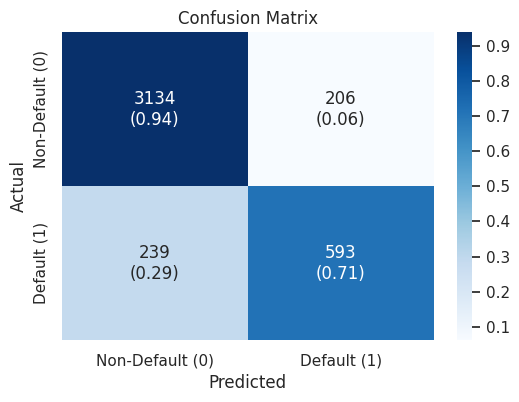

Metric Summary:
 ------------
Accuracy: 0.8933
Precision: 0.7422
Recall: 0.7127
F1 Score: 0.7272
ROC-AUC: 0.8990


In [120]:
print(f"-"*20, "\nTrain Performance:\n", "-"*20)
dtree_tuned_train_scores = metrics_score(y_train, dtree_tuned_pred_train, dtree_tuned_pred_train_prob)

-------------------- 
Test Performance:
 --------------------
Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.94      0.93      1431
           1       0.74      0.64      0.69       357

    accuracy                           0.88      1788
   macro avg       0.83      0.79      0.81      1788
weighted avg       0.88      0.88      0.88      1788



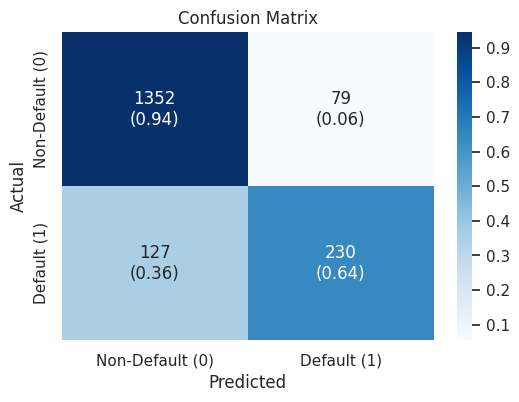

Metric Summary:
 ------------
Accuracy: 0.8848
Precision: 0.7443
Recall: 0.6443
F1 Score: 0.6907
ROC-AUC: 0.8780


In [103]:
print(f"-"*20, "\nTest Performance:\n", "-"*20)
dtree_tuned_test_scores = metrics_score(y_test, dtree_tuned_pred_test, dtree_tuned_pred_test_prob)

- Tuning significantly reduced overfitting, with train and test performance now much closer.
- The model shows stable generalization, unlike the baseline tree.
- Compared to the baseline decision tree:
  - Train performance dropped (as expected), indicating reduced memorization.
  - Test performance is more reliable, confirming improved model robustness.

- Compared to logistic regression (threshold = 0.35):
  - Recall for defaulters is lower(~64% vs ~71%), meaning it misses more high-risk applicants.
  - Precision is slightly higher (~74%), indicating fewer false positives.
  - F1-score is slightly lower, showing a weaker balance overall.
  - ROC-AUC (0.88) is still lower than logistic regression (0.90), indicating weaker discrimination.

Tuning successfully controlled overfitting and improved generalization.

However, the tuned decision tree still underperforms the threshold-tuned logistic regression in detecting defaulters.

Logistic regression remains the stronger and more reliable model at this stage.

---------------------------------------- 
Test Performance at threshold = 0.35 
 ----------------------------------------
Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.94      0.93      1431
           1       0.73      0.68      0.70       357

    accuracy                           0.89      1788
   macro avg       0.83      0.81      0.82      1788
weighted avg       0.88      0.89      0.88      1788



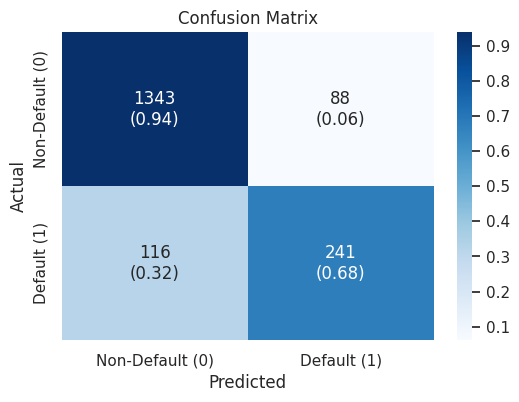

Metric Summary:
 ------------
Accuracy: 0.8859
Precision: 0.7325
Recall: 0.6751
F1 Score: 0.7026
ROC-AUC: 0.8780


In [124]:
threshold = 0.35

# Apply threshold
dtree_thresh = (dtree_tuned_pred_test_prob >= threshold).astype(int)

# Evaluate
print(f"-"*40, "\nTest Performance at threshold =", threshold, "\n", "-"*40)
metrics_score(y_test, dtree_thresh, dtree_tuned_pred_test_prob)

### **Random Forest Classifier (Ensemble Model)**


Random Forest is an ensemble method that builds multiple decision trees and combines their predictions. This helps reduce overfitting and improves generalization compared to a single decision tree.


### Baseline Model

In [142]:
# Initialize model
rf = RandomForestClassifier(random_state=1)

# Fit model
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=1)

### Predictions

In [143]:
# Train
rf_pred_train = rf.predict(X_train)
rf_pred_train_prob = rf.predict_proba(X_train)[:, 1]

# Test
rf_pred_test = rf.predict(X_test)
rf_pred_test_prob = rf.predict_proba(X_test)[:, 1]

### Evaluation

-------------------- 
Train Performance:
 --------------------
Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3340
           1       1.00      1.00      1.00       832

    accuracy                           1.00      4172
   macro avg       1.00      1.00      1.00      4172
weighted avg       1.00      1.00      1.00      4172



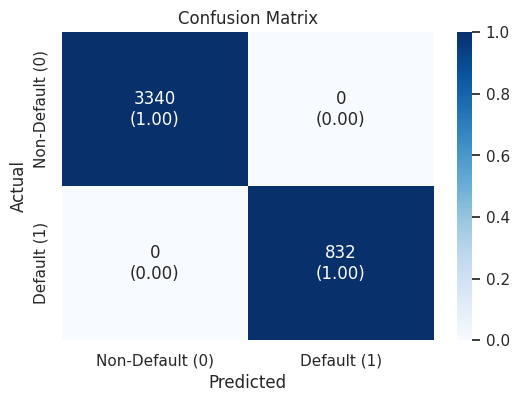

Metric Summary:
 ------------
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
ROC-AUC: 1.0000


In [107]:
print(f"-"*20, "\nTrain Performance:\n", "-"*20)
rf_train_scores = metrics_score(y_train, rf_pred_train, rf_pred_train_prob)

-------------------- 
Test Performance:
 --------------------
Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      1431
           1       0.81      0.66      0.73       357

    accuracy                           0.90      1788
   macro avg       0.86      0.81      0.83      1788
weighted avg       0.90      0.90      0.90      1788



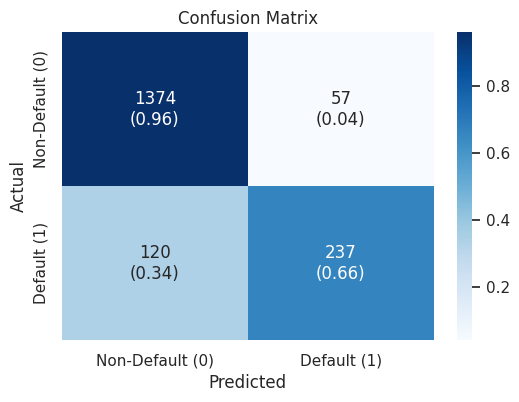

Metric Summary:
 ------------
Accuracy: 0.9010
Precision: 0.8061
Recall: 0.6639
F1 Score: 0.7281
ROC-AUC: 0.9496


In [108]:
print(f"-"*20, "\nTest Performance:\n", "-"*20)
rf_test_scores = metrics_score(y_test, rf_pred_test, rf_pred_test_prob)

- The model achieves perfect training performance, indicating overfitting.
- Test performance is strong, with ~90% accuracy and improved generalization compared to decision trees.

- Compared to logistic regression (threshold = 0.35):
  - Recall is slightly lower (~68% vs ~71%), meaning it still misses more defaulters.
  - Precision is higher (~81%), indicating more reliable default predictions.
  - F1-score is slightly higher, showing a better balance overall.
  - ROC-AUC is highest (~0.95), indicating the strongest discrimination ability among all models so far.

Random Forest provides the best overall performance, especially in terms of ROC-AUC and balanced metrics.

However, it shows signs of overfitting and is still less effective than tuned logistic regression in detecting defaulters, which remains critical for this problem.

Further tuning may improve recall while maintaining strong overall performance.

### Threshold Tuning

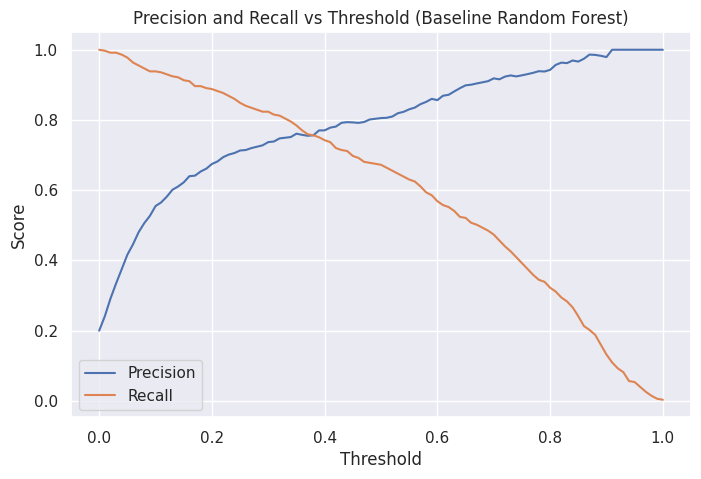

In [109]:
# Get predicted probabilities for the positive class
rf_pred_test_prob = rf.predict_proba(X_test)[:, 1]

# Compute precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, rf_pred_test_prob)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold (Baseline Random Forest)")
plt.legend()
plt.grid(True)
plt.show()

---------------------------------------- 
Test Performance at threshold = 0.37 
 ----------------------------------------
Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1431
           1       0.75      0.76      0.76       357

    accuracy                           0.90      1788
   macro avg       0.85      0.85      0.85      1788
weighted avg       0.90      0.90      0.90      1788



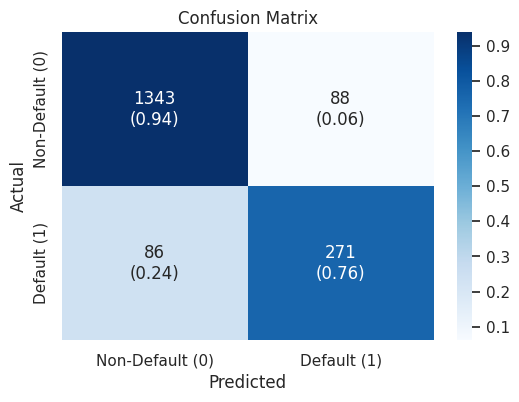

Metric Summary:
 ------------
Accuracy: 0.9027
Precision: 0.7549
Recall: 0.7591
F1 Score: 0.7570
ROC-AUC: 0.9496


In [140]:
threshold = 0.37

# Apply threshold
rf_pred_test_thresh = (rf_pred_test_prob >= threshold).astype(int)

# Evaluate
print(f"-"*40, "\nTest Performance at threshold =", threshold, "\n", "-"*40)
metrics_score(y_test, rf_pred_test_thresh, rf_pred_test_prob)

- Threshold tuning significantly improved recall for defaulters (~67% → ~76%), making the model much better at identifying high-risk applicants.
- Precision decreased slightly (~80% → ~75%), indicating more false positives, but still remains reasonable.
- F1-score improved (~0.73 → ~0.76), showing a stronger balance between precision and recall.
- Accuracy remains stable (~90%), indicating no loss in overall performance.
- ROC-AUC remains very high (~0.95), confirming strong overall discrimination.

After threshold tuning, Random Forest now outperforms logistic regression in both recall and overall balance.
The model becomes more aligned with the business goal, effectively prioritizing detection of defaulters.

This model is so far the strongest, combining high recall with excellent overall performance.
However, it still shows signs of overfitting.

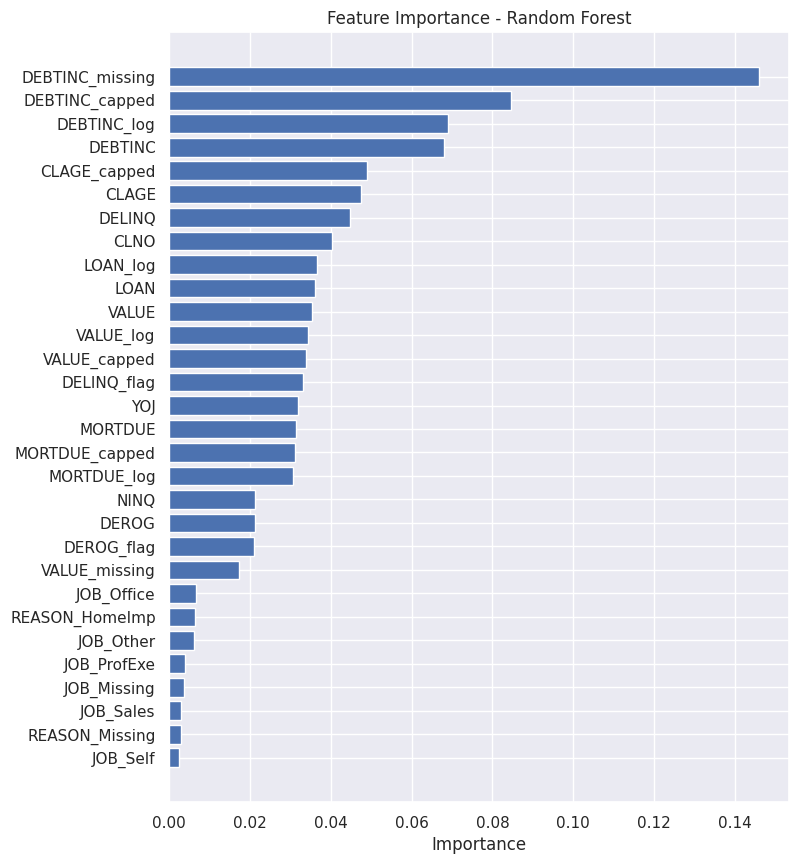

In [150]:
# Get feature importance
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

# Sort
rf_importance = rf_importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 10))
plt.barh(rf_importance["Feature"], rf_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()

The random forest model reinforces the findings from logistic regression, with debt-to-income ratio (DEBTINC) and missing debt-to-income information as the most influential predictors of default. This confirms that a borrower’s debt burden is the primary driver of credit risk.

Credit history variables such as CLAGE and DELINQ also play a significant role, indicating that both the length and quality of credit history are important factors in repayment behavior.

Loan and property-related variables (e.g., LOAN, VALUE, MORTDUE) contribute moderately, while categorical features such as job type and loan purpose have relatively low importance.

Overall, the model highlights that financial stability (debt load) and credit behavior are far more predictive of default than demographic or loan-purpose attributes.


### **Random Forest Classifier Hyperparameter Tuning**

Grid search with cross-validation is used to find the best combination of hyperparameters. The tuning focuses on:
- number of trees,
- tree depth,
- minimum samples required for splits and leaves,
- number of features considered at each split.

This helps improve generalization and potentially increase recall for defaulters while maintaining strong overall performance.

In [111]:
# Base model
rf = RandomForestClassifier(
    random_state=1,
    class_weight="balanced",
    n_jobs=-1
)

# Parameter grid
param_grid_rf = {
    "n_estimators": [200, 300],
    "max_depth": [8, 12, None],
    "min_samples_split": [10, 20],
    "min_samples_leaf": [2, 5],
    "max_features": ["sqrt"]
}

# Grid search
grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

# fit
grid_search_rf.fit(X_train, y_train)

# Best model
rf_tuned = grid_search_rf.best_estimator_

print("Best Parameters:", grid_search_rf.best_params_)
print("Best CV Score:", grid_search_rf.best_score_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
Best CV Score: 0.7306290638278226


### Prediction

In [112]:
# Train
rf_tuned_pred_train = rf_tuned.predict(X_train)
rf_tuned_pred_train_prob = rf_tuned.predict_proba(X_train)[:, 1]

# Test
rf_tuned_pred_test = rf_tuned.predict(X_test)
rf_tuned_pred_test_prob = rf_tuned.predict_proba(X_test)[:, 1]

### Evaluation

-------------------- 
Train Performance:
 --------------------
Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.94      0.96      3340
           1       0.81      0.93      0.87       832

    accuracy                           0.94      4172
   macro avg       0.90      0.94      0.91      4172
weighted avg       0.95      0.94      0.94      4172



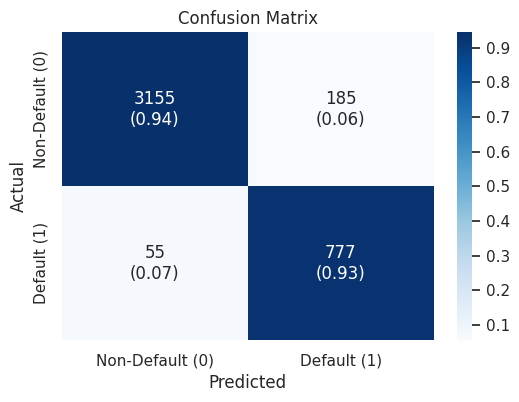

Metric Summary:
 ------------
Accuracy: 0.9425
Precision: 0.8077
Recall: 0.9339
F1 Score: 0.8662
ROC-AUC: 0.9882


In [113]:
print(f"-"*20, "\nTrain Performance:\n", "-"*20)
metrics_score(y_train, rf_tuned_pred_train, rf_tuned_pred_train_prob)

-------------------- 
Test Performance:
 --------------------
Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      1431
           1       0.72      0.72      0.72       357

    accuracy                           0.89      1788
   macro avg       0.83      0.83      0.83      1788
weighted avg       0.89      0.89      0.89      1788



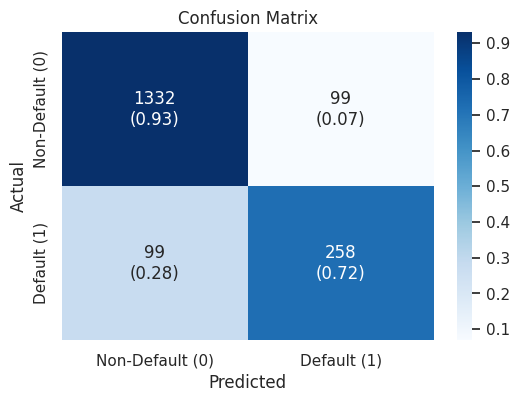

Metric Summary:
 ------------
Accuracy: 0.8893
Precision: 0.7227
Recall: 0.7227
F1 Score: 0.7227
ROC-AUC: 0.9361


In [114]:
print(f"-"*20, "\nTest Performance:\n", "-"*20)
rf_tuned_test_scores = metrics_score(y_test, rf_tuned_pred_test, rf_tuned_pred_test_prob)

- The tuned random forest achieves balanced performance with recall (~72%) and precision (~72%), competitive with the logistic regression (threshold = 0.35) on both metrics.

- Compared to the random forest classifier (threshold = 0.37):
  - Recall is lower (~72% vs ~76%), meaning it detects less defaulters.
  - Precision is lower (~72% vs ~75%), indicating more false positives.
  - F1-score is lower, showing weaker overall balance.
  - ROC-AUC is slightly lower (~0.94 vs ~0.95), though both models have strong discrimination.


Despite tuning and handling class imbalance, the model does not outperform the threshold-tuned random forest, which remains the best-performing model, achieving stronger recall, precision, and overall balance.

### Threshold Tuning

---------------------------------------- 
Test Performance at threshold =  0.37 
 ----------------------------------------
Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.90      0.92      1431
           1       0.66      0.80      0.73       357

    accuracy                           0.88      1788
   macro avg       0.81      0.85      0.83      1788
weighted avg       0.89      0.88      0.88      1788



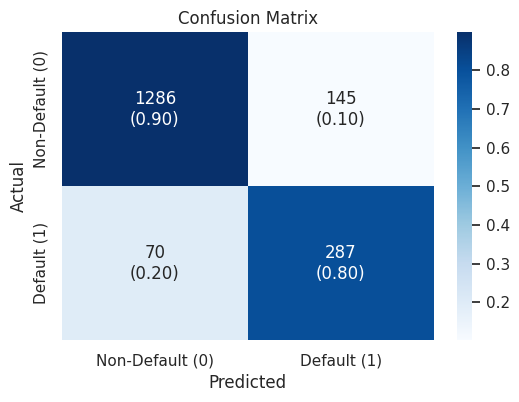

Metric Summary:
 ------------
Accuracy: 0.8798
Precision: 0.6644
Recall: 0.8039
F1 Score: 0.7275
ROC-AUC: 0.9361


In [115]:
threshold = 0.37

rf_tuned_pred_test_thresh = (rf_tuned_pred_test_prob >= threshold).astype(int)

print(f"-"*40, "\nTest Performance at threshold = ", threshold, "\n", "-"*40)
metrics_score(y_test, rf_tuned_pred_test_thresh, rf_tuned_pred_test_prob)

- Threshold tuning significantly shifted the model toward detecting defaulters, with recall increasing to ~80%, the highest so far.
- This comes at the cost of lower precision (~66%), indicating more false positives (more good applicants flagged as risky).
- Overall accuracy dropped (~88%), reflecting the trade-off from prioritizing the minority class.
- The model shows better balance in recall across classes, but with reduced performance on non-defaulters.


This is highly effective at capturing defaulters, aligning well with the business objective.

However, it becomes aggressive, leading to more false positives.

This model is suitable if the bank prioritizes risk minimization over customer acceptance.

### Model Comparison

| Model                 | Threshold | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
| --------------------- | --------- | -------- | --------- | ------ | -------- | ------- |
| Logistic Regression   | 0.50      | 0.8893   | 0.8000    | 0.5938 | 0.6817   | 0.9049  |
| Logistic Regression   | 0.35      | 0.8859   | 0.7179    | 0.7059 | 0.7119   | 0.9049  |
| Decision Tree (Tuned) | 0.50      | 0.8780   | 0.7443    | 0.6443 | 0.6907   | 0.8780  |
| Decision Tree (Tuned) | 0.35      | 0.8800   | 0.7325    | 0.6751 | 0.7026   | 0.8780  |
| Random Forest         | 0.50      | 0.9027   | 0.8061    | 0.6639 | 0.7281   | 0.9496  |
| Random Forest         | 0.37      | 0.9027   | 0.7549    | 0.7591 | 0.7570   | 0.9496  |
| Tuned Random Forest   | 0.50      | 0.8893   | 0.7227    | 0.7227 | 0.7227   | 0.9361  |
| Tuned Random Forest   | 0.37      | 0.8820   | 0.6644    | 0.8039 | 0.7275   | 0.9361  |


* Threshold tuning significantly improves recall across all models, which is critical for identifying defaulters.
* Logistic regression provides strong baseline performance with high interpretability but lower recall at default threshold.
* Decision trees show signs of overfitting and underperform compared to ensemble methods.
* Random forest achieves the best overall performance, especially in ROC-AUC and F1 score.
* Random forest (with threshold = 0.37) offers the best balance between precision and recall.
* The tuned random forest (with threshold = 0.37) achieves the highest recall, making it suitable when minimizing missed defaulters is the priority.

### Key Business Insights

**Default risk is primarily capacity-driven, not size-driven**
- Repayment ability (DEBTINC, delinquencies, derogatory history) matters more than the absolute loan amount.

**Credit behavior is more predictive than static profile features**
- Variables reflecting recent and past credit actions (DELINQ, DEROG, NINQ) consistently dominate risk signals over demographics or job type.

**There is a clear “high-risk borrower profile”**
- High debt burden + poor credit history + frequent credit inquiries → sharply elevated default probability.

**Loan purpose acts as a risk segmentation variable**
- Debt consolidation loans systematically carry higher risk, indicating underlying financial distress rather than asset-building intent.

**Stability reduces both uncertainty and risk**
- Longer job tenure and older credit lines reduce variability in outcomes, making these borrowers more predictable and safer.

**Missing data is a risk signal rather than a data issue**
- Incomplete financial disclosure is itself indicative of higher default likelihood and should be treated explicitly in decisioning.

**Threshold choice directly encodes business policy**
- Lower thresholds increase default detection (recall) at the cost of more false positives, reflecting a stricter lending strategy.

Overall, effective credit decisions should prioritize early detection of financial stress signals, alongside evaluation of current financial standing.


### Recommendations / Proposed Solution

**Adopt Random Forest (with threshold = 0.37) as the primary model**
- It provides the best balance between recall and precision while maintaining strong overall discrimination (ROC-AUC).

**Implement a risk-based approval strategy (not binary decisions)**
- This reduces unnecessary rejections while controlling default risk.
  * Low risk → approve
  * Medium risk → additional documentation and review
  * High risk → reject
    

**Incorporate key risk drivers into policy rules**
- Explicitly monitor variables such as DEBTINC, DELINQ, DEROG, and NINQ as part of approval guidelines.

**Treat missing financial information as a red flag**
- Applications with missing critical financial variables should trigger stricter review or conditional approval.

**Continuously monitor model performance and drift**
- Periodically retrain and validate the model to ensure stability as borrower behavior and economic conditions change.




### Scope for Improvement

* Incorporate cost-sensitive learning to directly reflect business risk (false negatives vs false positives).
* Explore gradient boosting models and probability calibration to further align predictions with business risk.


  